In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3

pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

pd.set_option('max_colwidth', None)

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [3]:
def replace_player(df_):
    df_.player.replace({'J.J. Redick':'JJ Redick'}, inplace=True)
    
    df_.player.replace({'A.J. Price': 'AJ Price'}, inplace=True)
    
    df_.player.replace({'Alex Ajinca':'Alexis Ajinca'}, inplace=True)
    
    df_.player.replace({'C.J. Miles': 'CJ Miles'}, inplace=True)
    
    df_.player.replace({'D.J. White': 'DJ White'}, inplace=True)
    
    df_.player.replace({"Hamady N'Diaye" : 'Hamady Ndiaye'}, inplace=True)
    
    df_.player.replace({'J.J. Hickson': 'JJ Hickson'}, inplace=True)
    
    df_.player.replace({'John Wallace' : 'John Wall'}, inplace=True)
    
    df_.player.replace({'Jose Barea' : 'J.J. Barea'}, inplace=True)
    
    df_.player.replace({'Wes Johnson':'Wesley Johnson'}, inplace=True)
    
    df_.player.replace({'B.J. Mullens':'Byron Mullens'}, inplace=True)
    
    df_.player.replace({'Bill Walker':'Henry Walker'}, inplace=True)
    
    df_.player.replace({'Gerald Henderson Jr.':'Gerald Henderson'}, inplace=True)
    
    df_.player.replace({'Jianlian Yi':'Yi Jianlian'}, inplace=True)
    
    df_.player.replace({'Mike Conley Jr.':'Mike Conley'}, inplace=True)
    
    df_.player.replace({'Mike Dunleavy Jr.':'Mike Dunleavy'}, inplace=True)
    
    df_.player.replace({'Nene Hilario': 'Nene'}, inplace=True)
    
    df_.player.replace({'Didier Mbenga':'DJ Mbenga'}, inplace=True)
    
    df_.player.replace({'A.J. Hammons':'AJ Hammons'}, inplace=True)
    
    df_.player.replace({'C.J. McCollum':'CJ McCollum'}, inplace=True)
    
    df_.player.replace({'D.J. Augustine':'D.J. Augustin'}, inplace=True)
    
    df_.player.replace({'DeAndre Bembry':"DeAndre' Bembry"}, inplace=True)
    
    df_.player.replace({'Giorgios Papagiannis':'Georgios Papagiannis'}, inplace=True)
    
    df_.player.replace({'Glen Rice Jr.':'Glen Rice'}, inplace=True)
    
    df_.player.replace({'J.R. Smith':'JR Smith'}, inplace=True)
    
    df_.player.replace({'James Ennis':'James Ennis III'}, inplace=True)
    
    df_.player.replace({'John Collins  John Collins':'John Collins'}, inplace=True)
    
    df_.player.replace({'Juan Hernangomez':'Juancho Hernangomez'}, inplace=True)
    
    df_.player.replace({'Billy Ouattara':'Yakuba Ouattara'}, inplace=True)
    
    df_.player.replace({'Courtney Simpson':'Diamon Simpson'}, inplace=True)
    
    df_.player.replace({'Danuel House':'Danuel House Jr.'}, inplace=True)
    
    df_.player.replace({'Domas Sabonis':'Domantas Sabonis'}, inplace=True)
    
    df_.player.replace({'Jake Wiley':'Jacob Wiley'}, inplace=True)
    
    df_.player.replace({'James McAdoo':'James Michael McAdoo'}, inplace=True)
    
    df_.player.replace({'Jeff Pendergraph':'Jeff Ayres'}, inplace=True)
    
    df_.player.replace({'Jeff Taylor':'Jeffery Taylor'}, inplace=True)
    
    df_.player.replace({'K.J. McDaniels':'KJ McDaniels'}, inplace=True)
    
    df_.player.replace({'K.J. McDaniels':'KJ McDaniels'}, inplace=True)
    
    df_.player.replace({'Malcom Lee':'Malcolm Lee'}, inplace=True)
    
    df_.player.replace({'Marcus Morris':'Marcus Morris Sr.'}, inplace=True)
    
    df_.player.replace({'Matt Williams':'Matt Williams Jr.'}, inplace=True)
    
    df_.player.replace({"Maurice N'dour":'Maurice Ndour'}, inplace=True)
    
    df_.player.replace({'Milos Tedosic':'Milos Teodosic'}, inplace=True)
    
    df_.player.replace({'Moe Harkless':'Maurice Harkless'}, inplace=True)
    
    df_.player.replace({'O.G. Anunoby':'OG Anunoby'}, inplace=True)
    
    df_.player.replace({'Ognen Kuzmic':'Ognjen Kuzmic'}, inplace=True)
    
    df_.player.replace({'P.J. Dozier':'PJ Dozier'}, inplace=True)
    
    df_.player.replace({'P.J. Hairston':'PJ Hairston'}, inplace=True)
    
    df_.player.replace({'Qi Zhou':'Zhou Qi'}, inplace=True)
    
    df_.player.replace({'R.J. Hunter':'RJ Hunter'}, inplace=True)
    
    df_.player.replace({'Ray McCallum Jr.':'Ray McCallum'}, inplace=True)
    
    df_.player.replace({'Ron Artest':'Metta World Peace'}, inplace=True)
    
    df_.player.replace({'Roy Marble':'Devyn Marble'}, inplace=True)
    
    df_.player.replace({'Stephen Zimmerman Jr.':'Stephen Zimmerman'}, inplace=True)
    
    df_.player.replace({'Tony Wroten Jr.':'Tony Wroten'}, inplace=True)
    
    df_.player.replace({'Toure Murry':"Toure' Murry"}, inplace=True)
    
    df_.player.replace({'Viacheslav Kravstov':'Viacheslav Kravtsov'}, inplace=True)
    
    df_.player.replace({'Vince Hunter':'Vincent Hunter'}, inplace=True)
    
    df_.player.replace({'Walker Russell Jr.':'Walker Russell'}, inplace=True)
    
    df_.player.replace({'Wayne Selden Jr.':'Wayne Selden'}, inplace=True)
    
    df_.player.replace({'Wes Matthews Jr.':'Wesley Matthews'}, inplace=True)
    
    return df_

#names dropped from Injury Report dataframe df_inj1018 for the following reasons:
#a. no player nba regular season or playoff boxscore advanced stats between the 2009-10 and 2017-18 seasons.
#b. player did not play an nba regular season or playoff game between the 2009-10 and 2017-18 seasons.
#c. no player nba regular season or playoff boxscore advanced stats between the 2009-10 and 2017-18 seasons. Player plays in nba games
#   following the 2017-18 season.
#d. this is the injury of a coach, not a player. coaches do not have boxscore advanced stats


def drop_player(df_):
    df_.drop(df_[df_.player.str.contains('Marion Hillard')].index, inplace = True) #a
    
    df_.drop(df_[df_.player.str.contains('Matt Janning')].index, inplace = True) #a
    
    df_.drop(df_[df_.player.str.contains("Da'Sean Butler")].index, inplace = True) #a
    
    df_.drop(df_[df_.player.str.contains('Eric Griffin')].index, inplace = True) #a
    
    df_.drop(df_[df_.player.str.contains('Harry Giles')].index, inplace = True) #c
    
    df_.drop(df_[df_.player.str.contains('Magnum Rolle')].index, inplace = True) #a
    
    df_.drop(df_[df_.player.str.contains('Robert Vaden')].index, inplace = True) #a
    
    df_.drop(df_[df_.player.str.contains('Steve Clifford')].index, inplace = True) #d
    
    df_.drop(df_[df_.player.str.contains('Steve Kerr')].index, inplace = True) #d
    
    df_.drop(df_[df_.player.str.contains('Terrico White')].index, inplace = True)#a
    
    df_.drop(df_[df_.player.str.contains('Tyronn Lue')].index, inplace = True) #d
    
    return df_

def df_inj1020_fix_Date_Team(df_):
    df_.loc[5923, ['Team']] = 'Pacers'
    return df_
  


def get_5bsa1018_inj1018_player_diff():
    print(len(set(df_inj1018.player) - set(df_5bsa1018.PLAYER_NAME)))
    print(set(df_inj1018.player) - set(df_5bsa1018.PLAYER_NAME))
    print()
    
    print(len(set(df_5bsa1018.PLAYER_NAME) - set(df_inj1020.player)))
    print(set(df_5bsa1018.PLAYER_NAME) - set(df_inj1020.player))
    return 0
    
    
#get injury data for player
def gi(player_):
    return df_inj1018[df_inj1018.player.str.contains(player_)] 

#get boxscore advance for player
def gb(player_):
    return df_5bsa1018[df_5bsa1018.PLAYER_NAME.str.contains(player_)]

#get inactive player game-by-game
def gia(player_):
    return df_ina1018[df_ina1018.player.str.contains(player_)]

#return first 5 and last 5 rows of dataframe
def p(df_):
    return pd.concat([df_.head(), df_.tail()])



In [4]:
def get_injury_and_win_lose():
    #get injury report for 2010-11 thru 2017-18 sesasons: df_inj1018

    #last game_date of 2017-18 season
    path = os.path.join('..', 'processed_data', '7season_first_game_date_last_game_date.csv')
    df_7sfgdlgd = pd.read_csv(path, parse_dates=['first', 'last'])
    last_game_date_s1718 = df_7sfgdlgd.iloc[8]['last']
    last_game_date_s1718

    #read in raw injury report
    path = os.path.join('..', 'raw_data', 'injuries_2010-2020.csv')
    df_inj1020 = pd.read_csv(path, parse_dates=['Date'])

    #preprocess player & Date
    df_inj1020.Acquired.fillna('', inplace=True)
    df_inj1020.Relinquished.fillna('', inplace=True)
    df_inj1020['player'] = df_inj1020.Relinquished + ' ' + df_inj1020.Acquired
    df_inj1020.player = df_inj1020.player.str.strip()
    df_inj1020 = df_inj1020_fix_Date_Team(df_inj1020)

    df_inj1018 = df_inj1020.loc[df_inj1020['Date'] <= last_game_date_s1718]
    df_inj1018 = replace_player(df_inj1018)
    df_inj1018 = drop_player(df_inj1018)

    #filter Date to game_date
    df_3gdgiti0618 = pd.read_csv(os.path.join('..', 'processed_data', '3game_id_game_date_team_id.csv'), parse_dates=['game_date'])
    df_3gdgi0618 = df_3gdgiti0618[['game_date', 'game_id']].drop_duplicates()
    df_3gd0618 = df_3gdgi0618.game_date.drop_duplicates()
    df_inj1018 = pd.merge(df_3gd0618.drop_duplicates(), df_inj1018.rename(columns={'Date':'game_date'}), on='game_date', how='inner')


    
    #check players stats on game_date relinquished (by injury) dates

    #get injury report games relinquished: df_inj1018r
    df_inj1018r = df_inj1018[df_inj1018.Relinquished != '']

    #read in nba boxscore advanced data for seasons 2009-10 thru 2017-18: df_5bsa1018
    df_5bsa1018 = pd.read_csv(os.path.join('..', 'processed_data', '5boxscoreadvancedv2_2009_2018.csv'))
    df_5bsa1018.PLAYER_NAME = df_5bsa1018.PLAYER_NAME.fillna('')
    df_5bsa1018 = pd.merge(df_3gdgi0618, df_5bsa1018.rename(columns={'GAME_ID':'game_id'}), on='game_id', how='inner')
    df_5bsa1018.MIN = df_5bsa1018.MIN.fillna('00:00')
    df_5bsa1018.MIN = pd.to_timedelta('00:' + df_5bsa1018.MIN).astype('timedelta64[s]').astype('float64') / 60
    df_5bsa1018.TEAM_ID = df_5bsa1018.TEAM_ID.fillna(0).astype('int64')
    
    #get 
    df_gdinj1018 = pd.merge(df_inj1018r, df_5bsa1018.rename(columns={'PLAYER_NAME':'player'}), how='inner', on=['game_date', 'player'])
    
    df_gdinj1018[['E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TOV', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'POSS', 'PIE']] = df_gdinj1018[['E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TOV', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'POSS', 'PIE']].fillna(0)
    
    df_gdinj1018['ig_player_injury'] = 0
    df_gdinj1018.loc[df_gdinj1018.MIN != 0, 'ig_player_injury'] = 1
    
    df_temp = df_gdinj1018[df_gdinj1018.MIN != 0][['game_id','TEAM_ID', 'ig_player_injury']]
    df_temp['pts'] = 0
    
    df_temp2 = df_3gdgiti0618[['game_id', 'team_id', 'pts']]
    df_temp2['ig_player_injury'] = 0
    df_temp2 = pd.merge(df_temp.game_id.drop_duplicates(), df_temp2, how='left', on='game_id')
    
    df_temp = pd.concat([df_temp.rename(columns={'TEAM_ID':'team_id'}), df_temp2])
    
    df_temp = df_temp.groupby(['game_id', 'team_id']).sum()
    
    df_temp.reset_index(inplace=True)
    
    df_temp = df_temp[(df_temp.game_id != 21000342) &
                                          (df_temp.game_id != 21000646) &
                                          (df_temp.game_id != 21500064) &
                                          (df_temp.game_id != 21600060) &
                                         (df_temp.game_id != 21600176) &
                                         (df_temp.game_id != 21600663) &
                                         (df_temp.game_id != 21600834) &
                                         (df_temp.game_id != 41500213) &
                                         (df_temp.game_id != 41600311)]
    
    game_id_winlose = set(df_temp.game_id)
    
    injury_wl = pd.DataFrame({'injury_&_win':[0], 'injury_&_lose':[0]})
    
    for gi in game_id_winlose:

        injury_wl['injury_&_win']

        df_temp[['ig_player_injury', 'pts']].reset_index(drop=True)

        df_ip = df_temp[df_temp.game_id == gi][['ig_player_injury', 'pts']].reset_index(drop=True)
        df_ip = df_ip.reset_index(drop=True)
        if (df_ip.iloc[0,0] > df_ip.iloc[1,0]) & (df_ip.iloc[0,1] > df_ip.iloc[1,1]):
            injury_wl['injury_&_win'] = injury_wl['injury_&_win'] + 1
        if (df_ip.iloc[0,0] > df_ip.iloc[1,0]) & (df_ip.iloc[0,1] < df_ip.iloc[1,1]):
            injury_wl['injury_&_lose'] = injury_wl['injury_&_lose'] + 1
        if (df_ip.iloc[0,0] < df_ip.iloc[1,0]) & (df_ip.iloc[0,1] < df_ip.iloc[1,1]):
            injury_wl['injury_&_win'] = injury_wl['injury_&_win'] + 1
        if (df_ip.iloc[0,0] < df_ip.iloc[1,0]) & (df_ip.iloc[0,1] > df_ip.iloc[1,1]):
            injury_wl['injury_&_lose'] = injury_wl['injury_&_lose'] + 1

    return injury_wl
    

In [5]:
def get_df_ts_check():
        #get injury report for 2010-11 thru 2017-18 sesasons: df_inj1018

    #last game_date of 2017-18 season
    path = os.path.join('..', 'processed_data', '7season_first_game_date_last_game_date.csv')
    df_7sfgdlgd = pd.read_csv(path, parse_dates=['first', 'last'])
    last_game_date_s1718 = df_7sfgdlgd.iloc[8]['last']
    last_game_date_s1718

    #read in raw injury report
    path = os.path.join('..', 'raw_data', 'injuries_2010-2020.csv')
    df_inj1020 = pd.read_csv(path, parse_dates=['Date'])

    #preprocess player & Date
    df_inj1020.Acquired.fillna('', inplace=True)
    df_inj1020.Relinquished.fillna('', inplace=True)
    df_inj1020['player'] = df_inj1020.Relinquished + ' ' + df_inj1020.Acquired
    df_inj1020.player = df_inj1020.player.str.strip()
    df_inj1020 = df_inj1020_fix_Date_Team(df_inj1020)

    df_inj1018 = df_inj1020.loc[df_inj1020['Date'] <= last_game_date_s1718]
    df_inj1018 = replace_player(df_inj1018)
    df_inj1018 = drop_player(df_inj1018)

    #filter Date to game_date
    df_3gdgiti0618 = pd.read_csv(os.path.join('..', 'processed_data', '3game_id_game_date_team_id.csv'), parse_dates=['game_date'])
    df_3gdgi0618 = df_3gdgiti0618[['game_date', 'game_id']].drop_duplicates()
    df_3gd0618 = df_3gdgi0618.game_date.drop_duplicates()
    df_inj1018 = pd.merge(df_3gd0618.drop_duplicates(), df_inj1018.rename(columns={'Date':'game_date'}), on='game_date', how='inner')


    
    #check players stats on game_date relinquished (by injury) dates

    #get injury report games relinquished: df_inj1018r
    df_inj1018r = df_inj1018[df_inj1018.Relinquished != '']

    #read in nba boxscore advanced data for seasons 2009-10 thru 2017-18: df_5bsa1018
    df_5bsa1018 = pd.read_csv(os.path.join('..', 'processed_data', '5boxscoreadvancedv2_2009_2018.csv'))
    df_5bsa1018.PLAYER_NAME = df_5bsa1018.PLAYER_NAME.fillna('')
    df_5bsa1018 = pd.merge(df_3gdgi0618, df_5bsa1018.rename(columns={'GAME_ID':'game_id'}), on='game_id', how='inner')
    df_5bsa1018.MIN = df_5bsa1018.MIN.fillna('00:00')
    df_5bsa1018.MIN = pd.to_timedelta('00:' + df_5bsa1018.MIN).astype('timedelta64[s]').astype('float64') / 60
    df_5bsa1018.TEAM_ID = df_5bsa1018.TEAM_ID.fillna(0).astype('int64')
    
    #get 
    df_gdinj1018 = pd.merge(df_inj1018r, df_5bsa1018.rename(columns={'PLAYER_NAME':'player'}), how='inner', on=['game_date', 'player'])
    
    df_gdinj1018[['E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TOV', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'POSS', 'PIE']] = df_gdinj1018[['E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TOV', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'POSS', 'PIE']].fillna(0)
    
    df_gdinj1018['ig_player_injury'] = 0
    df_gdinj1018.loc[df_gdinj1018.MIN != 0, 'ig_player_injury'] = 1
    
    
    df_3gdgiti0618 = pd.read_csv(os.path.join('..', 'processed_data', '3game_id_game_date_team_id.csv'), parse_dates=['game_date'])
    
    df_ts_check = pd.merge(df_3gdgiti0618[['game_id', 'season']].drop_duplicates().reset_index(drop=True), df_gdinj1018, on=['game_id'], how='inner')
    
    return df_ts_check

In [6]:
get_injury_and_win_lose()

/opt/anaconda3/lib/python3.8/site-packages/pandas/core/series.py:4563: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().replace(
/opt/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(
<ipython-input-4-362c20f8955e>:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp2['ig_player_inj

,injury_&_win,injury_&_lose
0,87,102


In [7]:
#df_inj1020[(df_inj1020.Team == 'Bucks') & (df_inj1020.Date == pd.Timestamp('2013-01-05')) & (df_inj1020.player == 'Sam Young')]


In [8]:
#df_inj1020.loc[5923, ['Team']]

In [9]:
#df_inj1020.loc[5923, ['Team']] = 'Pacers'

In [10]:
#df_inj1020.loc[5923, ['Team']]

In [11]:
os.getcwd()

'/Users/pauljacob/Documents/GitHub/DSCapstone2/02_Data_Wrangling'

In [12]:
#get injury report for 2010-11 thru 2017-18 sesasons: df_inj1018

#last game_date of 2017-18 season
path = os.path.join('..', 'processed_data', '7season_first_game_date_last_game_date.csv')
df_7sfgdlgd = pd.read_csv(path, parse_dates=['first', 'last'])
last_game_date_s1718 = df_7sfgdlgd.iloc[8]['last']
last_game_date_s1718

#read in raw injury report
path = os.path.join('..', 'raw_data', 'injuries_2010-2020.csv')
df_inj1020 = pd.read_csv(path, parse_dates=['Date'])

#preprocess player & Date
df_inj1020.Acquired.fillna('', inplace=True)
df_inj1020.Relinquished.fillna('', inplace=True)
df_inj1020['player'] = df_inj1020.Relinquished + ' ' + df_inj1020.Acquired
df_inj1020.player = df_inj1020.player.str.strip()
df_inj1020 = df_inj1020_fix_Date_Team(df_inj1020)

df_inj1018 = df_inj1020.loc[df_inj1020['Date'] <= last_game_date_s1718]
df_inj1018 = replace_player(df_inj1018)
df_inj1018 = drop_player(df_inj1018)

#filter Date to game_date
df_3gdgiti0618 = pd.read_csv(os.path.join('..', 'processed_data', '3game_id_game_date_team_id.csv'), parse_dates=['game_date'])
df_3gdgi0618 = df_3gdgiti0618[['game_date', 'game_id']].drop_duplicates()
df_3gd0618 = df_3gdgi0618.game_date.drop_duplicates()
df_inj1018 = pd.merge(df_3gd0618.drop_duplicates(), df_inj1018.rename(columns={'Date':'game_date'}), on='game_date', how='inner')
p(df_inj1018)


/opt/anaconda3/lib/python3.8/site-packages/pandas/core/series.py:4563: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().replace(
/opt/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,game_date,Team,Acquired,Relinquished,Notes,player
0,2010-10-26,Blazers,,Elliot Williams,placed on IL,Elliot Williams
1,2010-10-26,Blazers,,Greg Oden,placed on IL with left knee injury (out for season),Greg Oden
2,2010-10-26,Blazers,,Joel Przybilla,placed on IL placed on IL recovering from surgery on right knee to repair ruptured patella tendon,Joel Przybilla
3,2010-10-26,Celtics,,Avery Bradley,placed on IL recovering from surgery on left ankle,Avery Bradley
4,2010-10-26,Celtics,,Kendrick Perkins,placed on IL recovering from surgery on right knee to repair torn ACL,Kendrick Perkins
21916,2018-05-22,Warriors,,Andre Iguodala,bruised left leg (DTD),Andre Iguodala
21917,2018-05-26,Cavaliers,,Kevin Love,concussion (DTD),Kevin Love
21918,2018-05-26,Warriors,Patrick McCaw,,activated from IL,Patrick McCaw
21919,2018-05-31,Cavaliers,Kevin Love,,returned to lineup,Kevin Love
21920,2018-06-06,Warriors,Andre Iguodala,,returned to lineup,Andre Iguodala


In [13]:
#check players stats on game_date relinquished (by injury) dates

#get injury report games relinquished: df_inj1018r
df_inj1018r = df_inj1018[df_inj1018.Relinquished != '']

#read in nba boxscore advanced data for seasons 2009-10 thru 2017-18: df_5bsa1018
df_5bsa1018 = pd.read_csv(os.path.join('..', 'processed_data', '5boxscoreadvancedv2_2009_2018.csv'))
df_5bsa1018.PLAYER_NAME = df_5bsa1018.PLAYER_NAME.fillna('')
df_5bsa1018 = pd.merge(df_3gdgi0618, df_5bsa1018.rename(columns={'GAME_ID':'game_id'}), on='game_id', how='inner')
df_5bsa1018.MIN = df_5bsa1018.MIN.fillna('00:00')
df_5bsa1018.MIN = pd.to_timedelta('00:' + df_5bsa1018.MIN).astype('timedelta64[s]').astype('float64') / 60
df_5bsa1018.TEAM_ID = df_5bsa1018.TEAM_ID.fillna(0).astype('int64')

df_5bsa1018


,game_date,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
0,2009-10-27,20900001,1610612738,BOS,Boston,1718.0,Paul Pierce,F,NaN,37.983333,95.3,97.4,96.5,98.6,-1.2,-1.3,0.053,0.50,4.8,0.028,0.270,0.151,9.5,0.538,0.661,0.233,0.239,96.88,94.76,78.97,76.0,0.189
1,2009-10-27,20900001,1610612738,BOS,Boston,708.0,Kevin Garnett,F,NaN,33.083333,95.6,95.5,101.0,103.1,-5.4,-7.6,0.059,1.00,7.1,0.097,0.233,0.164,7.1,0.500,0.553,0.178,0.181,95.96,95.03,79.19,66.0,0.147
2,2009-10-27,20900001,1610612738,BOS,Boston,2570.0,Kendrick Perkins,C,NaN,25.700000,99.2,100.0,108.2,104.3,-9.1,-4.3,0.077,0.33,9.1,0.000,0.050,0.024,27.3,0.571,0.605,0.196,0.198,86.53,87.77,73.14,47.0,0.030
3,2009-10-27,20900001,1610612738,BOS,Boston,951.0,Ray Allen,G,NaN,42.350000,105.2,108.8,105.4,105.1,-0.2,3.7,0.120,1.00,12.5,0.000,0.054,0.028,12.5,0.375,0.440,0.236,0.240,91.50,90.12,75.10,80.0,0.051
4,2009-10-27,20900001,1610612738,BOS,Boston,200765.0,Rajon Rondo,G,NaN,34.483333,92.7,94.1,98.0,97.1,-5.3,-3.0,0.526,5.00,50.0,0.061,0.125,0.092,10.0,0.500,0.500,0.130,0.133,95.63,95.36,79.46,68.0,0.158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291638,2018-06-08,41700404,1610612739,CLE,Cleveland,1626204.0,Larry Nance Jr.,NaN,NaN,23.200000,93.4,97.6,93.1,95.2,0.3,2.3,0.333,0.00,33.3,0.176,0.077,0.133,0.0,0.429,0.444,0.148,0.146,88.76,85.87,71.56,41.0,0.139
291639,2018-06-08,41700404,1610612739,CLE,Cleveland,1626224.0,Cedi Osman,NaN,NaN,4.050000,100.0,114.3,76.1,75.0,23.9,39.3,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.333,0.333,0.333,0.333,94.10,88.89,74.07,7.0,0.000
291640,2018-06-08,41700404,1610612739,CLE,Cleveland,101181.0,Jose Calderon,NaN,NaN,4.050000,100.0,114.3,76.1,75.0,23.9,39.3,0.250,0.00,50.0,0.000,0.200,0.100,0.0,0.000,0.000,0.111,0.111,94.10,88.89,74.07,7.0,0.174
291641,2018-06-08,41700404,1610612739,CLE,Cleveland,1627790.0,Ante Zizic,NaN,NaN,1.666667,100.0,133.3,0.0,0.0,100.0,133.3,0.000,0.00,0.0,0.333,0.000,0.200,0.0,1.000,1.000,0.400,0.400,100.80,86.40,72.00,3.0,2.250


In [14]:
#game_date's nba player relinquished by injury report. expected df_ina1018 to include game_date inactive and relinquished
df_gdinj1018 = pd.merge(df_inj1018r, df_5bsa1018.rename(columns={'PLAYER_NAME':'player'}), how='inner', on=['game_date', 'player'])
df_gdinj1018

,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
0,2010-10-26,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,21000001,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN
1,2010-10-27,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,21000010,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN
2,2010-10-27,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,21000010,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN
3,2010-10-29,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000024,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN
4,2010-10-30,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000035,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6663,2017-05-22,Spurs,,Kawhi Leonard,sprained left ankle (out for season),Kawhi Leonard,41600314,1610612759,SAS,San Antonio,202695.0,NaN,DND - Sprained Left ankle,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN
6664,2018-04-20,Pacers,,Thaddeus Young,placed on IL with sinus infection,Thaddeus Young,41700133,1610612754,IND,Indiana,201152.0,F,NaN,33.383333,97.5,101.5,100.4,98.5,-3.0,3.1,0.056,1.0,8.3,0.167,0.065,0.115,8.3,0.6,0.6,0.145,0.149,95.19,94.16,78.47,65.0,0.14
6665,2018-04-23,Timberwolves,,Tyus Jones,sore right knee (DTD),Tyus Jones,41700144,1610612750,MIN,Minnesota,1626145.0,NaN,DNP - Coach's Decision,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN
6666,2018-04-30,Celtics,,Jaylen Brown,strained right hamstring (DTD),Jaylen Brown,41700211,1610612738,BOS,Boston,1627759.0,NaN,DND - Injury/Illness,0.000000,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0.0,NaN


In [15]:
df_gdinj1018.columns

Index(['game_date', 'Team', 'Acquired', 'Relinquished', 'Notes', 'player',
       'game_id', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_CITY', 'PLAYER_ID',
       'START_POSITION', 'COMMENT', 'MIN', 'E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TOV', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'POSS', 'PIE'],
      dtype='object')

In [16]:
df_gdinj1018[['E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TOV', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'POSS', 'PIE']] = df_gdinj1018[['E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TOV', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'POSS', 'PIE']].fillna(0)

In [17]:
#filter for games played by injured player by MIN (minutes played)

print(df_gdinj1018.shape)
df_gdinj1018.head()

(6668, 36)


,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
0,2010-10-26,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,21000001,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2010-10-27,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,21000010,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2010-10-27,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,21000010,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2010-10-29,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000024,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2010-10-30,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000035,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
#played in nba game (where West and Evans appear to have in game injuries)
print(df_gdinj1018[df_gdinj1018.MIN != 0].shape)
df_gdinj1018[df_gdinj1018.MIN != 0]

(209, 36)


,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
70,2010-11-24,Celtics,,Delonte West,broken right wrist (out indefinitely),Delonte West,21000212,1610612738,BOS,Boston,2753.0,NaN,NaN,11.916667,66.7,66.7,117.0,104.3,-50.3,-37.7,0.400,0.00,33.3,0.000,0.000,0.000,0.0,0.500,0.500,0.160,0.167,83.62,88.62,73.85,21.0,0.154
74,2010-11-26,Raptors,,Reggie Evans,broken right foot (out indefinitely),Reggie Evans,21000224,1610612761,TOR,Toronto,2501.0,F,NaN,20.216667,82.8,78.6,129.5,130.0,-46.7,-51.4,0.000,0.00,0.0,0.130,0.273,0.176,16.7,0.667,0.673,0.122,0.128,94.97,97.35,81.12,42.0,0.094
114,2010-12-11,Bulls,,Kurt Thomas,placed on IL,Kurt Thomas,21000345,1610612741,CHI,Chicago,703.0,NaN,NaN,3.333333,116.3,100.0,88.8,85.7,27.5,14.3,0.500,0.00,50.0,0.000,0.167,0.143,0.0,1.000,1.000,0.125,0.145,98.21,108.00,90.00,8.0,0.333
116,2010-12-11,Hawks,,Zaza Pachulia,placed on IL with illness,Zaza Pachulia,21000342,1610612737,ATL,Atlanta,2585.0,NaN,NaN,5.883333,107.8,110.0,108.7,127.3,-0.9,-17.3,0.333,1.00,50.0,0.200,0.167,0.182,50.0,0.000,0.000,0.083,0.082,94.15,85.67,71.39,10.0,0.057
119,2010-12-11,Pacers,,Jeff Foster,placed on IL,Jeff Foster,21000342,1610612754,IND,Indiana,1902.0,NaN,NaN,3.483333,114.2,150.0,111.1,114.3,3.1,35.7,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.500,0.500,0.250,0.254,104.15,89.78,74.82,6.0,0.100
128,2010-12-15,Bulls,,Joakim Noah,torn ligament in right thumb (out indefinitely),Joakim Noah,21000370,1610612741,CHI,Chicago,201149.0,C,NaN,26.216667,124.7,129.2,81.7,78.0,43.0,51.2,0.000,0.00,0.0,0.143,0.258,0.212,20.0,0.667,0.709,0.175,0.173,89.24,89.71,74.76,48.0,0.169
241,2011-01-14,Knicks,,Ronny Turiaf,right hip pointer (DTD),Ronny Turiaf,21000580,1610612752,NYK,New York,101142.0,C,NaN,15.933333,88.3,87.9,82.4,82.4,6.0,5.5,0.000,0.00,0.0,0.053,0.174,0.119,0.0,0.333,0.333,0.081,0.081,100.68,100.92,84.10,33.0,0.120
242,2011-01-14,Raptors,,Leandro Barbosa,strained right hamstring (DTD),Leandro Barbosa,21000578,1610612761,TOR,Toronto,2571.0,NaN,NaN,9.466667,119.6,115.8,131.0,130.0,-11.5,-14.2,0.200,1.00,14.3,0.000,0.111,0.050,14.3,0.250,0.205,0.250,0.256,96.96,98.89,82.41,19.0,-0.087
243,2011-01-14,Spurs,,Matt Bonner,sore right knee (DTD),Matt Bonner,21000581,1610612759,SAS,San Antonio,2588.0,NaN,NaN,7.900000,133.2,123.5,75.6,76.5,57.7,47.1,0.000,0.00,0.0,0.000,0.182,0.111,0.0,1.500,1.500,0.105,0.113,100.13,103.29,86.08,17.0,0.262
272,2011-01-21,Celtics,,Shaquille O'Neal,hip injury (DTD),Shaquille O'Neal,21000632,1610612738,BOS,Boston,406.0,C,NaN,6.316667,144.6,141.7,92.9,83.3,51.6,58.3,0.200,0.00,50.0,0.000,0.000,0.000,0.0,1.000,1.000,0.083,0.085,85.56,91.19,75.99,12.0,0.107


In [19]:
#did not play in nba game
print(df_gdinj1018[df_gdinj1018.MIN == 0].shape)
df_gdinj1018[df_gdinj1018.MIN == 0]

(6459, 36)


,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
0,2010-10-26,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,21000001,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2010-10-27,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,21000010,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2010-10-27,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,21000010,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2010-10-29,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000024,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2010-10-30,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000035,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6660,2017-05-23,Celtics,,Amir Johnson,sprained right shoulder (out for season),Amir Johnson,41600304,1610612738,BOS,Boston,101161.0,NaN,DNP - Coach's Decision,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6663,2017-05-22,Spurs,,Kawhi Leonard,sprained left ankle (out for season),Kawhi Leonard,41600314,1610612759,SAS,San Antonio,202695.0,NaN,DND - Sprained Left ankle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6665,2018-04-23,Timberwolves,,Tyus Jones,sore right knee (DTD),Tyus Jones,41700144,1610612750,MIN,Minnesota,1626145.0,NaN,DNP - Coach's Decision,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6666,2018-04-30,Celtics,,Jaylen Brown,strained right hamstring (DTD),Jaylen Brown,41700211,1610612738,BOS,Boston,1627759.0,NaN,DND - Injury/Illness,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<AxesSubplot:>

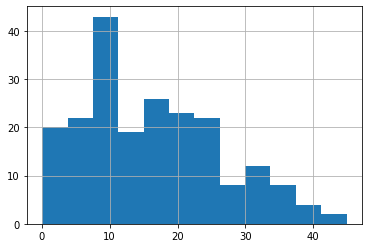

In [20]:
df_gdinj1018[df_gdinj1018.MIN != 0].MIN.hist(bins=12)

<AxesSubplot:>

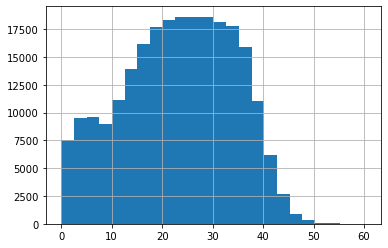

In [21]:
#player minutes distribution for 2009-10 thru 2017-18 season
df_5bsa1018.MIN[df_5bsa1018.MIN != 0].hist(bins=24)

In [22]:
df_5bsa1018.MIN[df_5bsa1018.MIN != 0].describe()

count    242096.000000
mean         23.127019
std          11.034678
min           0.016667
25%          15.050000
50%          23.750000
75%          31.933333
max          60.333333
Name: MIN, dtype: float64

In [23]:
df_5bsa1018.MIN[df_5bsa1018.MIN != 0].median()

23.75

In [24]:
df_gdinj1018.MIN.value_counts()

0.000000     6459
9.466667        3
8.733333        3
3.716667        2
15.583333       2
9.083333        2
15.933333       2
12.016667       2
17.666667       2
3.483333        2
21.816667       2
22.033333       2
5.250000        2
8.716667        1
12.883333       1
7.816667        1
4.966667        1
4.433333        1
9.050000        1
9.400000        1
8.266667        1
0.700000        1
4.683333        1
5.166667        1
19.083333       1
17.866667       1
13.283333       1
33.216667       1
10.250000       1
34.416667       1
15.083333       1
7.883333        1
14.050000       1
30.550000       1
3.350000        1
10.733333       1
18.066667       1
24.900000       1
30.650000       1
22.416667       1
25.183333       1
31.516667       1
22.733333       1
6.616667        1
10.850000       1
31.133333       1
15.683333       1
12.666667       1
11.150000       1
2.166667        1
16.750000       1
8.150000        1
2.900000        1
3.333333        1
6.316667        1
24.100000 

In [25]:
#nba games in which player gets injured
print(df_gdinj1018[df_gdinj1018.MIN != 0].shape)
df_gdinj1018[df_gdinj1018.MIN != 0]

(209, 36)


,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
70,2010-11-24,Celtics,,Delonte West,broken right wrist (out indefinitely),Delonte West,21000212,1610612738,BOS,Boston,2753.0,NaN,NaN,11.916667,66.7,66.7,117.0,104.3,-50.3,-37.7,0.400,0.00,33.3,0.000,0.000,0.000,0.0,0.500,0.500,0.160,0.167,83.62,88.62,73.85,21.0,0.154
74,2010-11-26,Raptors,,Reggie Evans,broken right foot (out indefinitely),Reggie Evans,21000224,1610612761,TOR,Toronto,2501.0,F,NaN,20.216667,82.8,78.6,129.5,130.0,-46.7,-51.4,0.000,0.00,0.0,0.130,0.273,0.176,16.7,0.667,0.673,0.122,0.128,94.97,97.35,81.12,42.0,0.094
114,2010-12-11,Bulls,,Kurt Thomas,placed on IL,Kurt Thomas,21000345,1610612741,CHI,Chicago,703.0,NaN,NaN,3.333333,116.3,100.0,88.8,85.7,27.5,14.3,0.500,0.00,50.0,0.000,0.167,0.143,0.0,1.000,1.000,0.125,0.145,98.21,108.00,90.00,8.0,0.333
116,2010-12-11,Hawks,,Zaza Pachulia,placed on IL with illness,Zaza Pachulia,21000342,1610612737,ATL,Atlanta,2585.0,NaN,NaN,5.883333,107.8,110.0,108.7,127.3,-0.9,-17.3,0.333,1.00,50.0,0.200,0.167,0.182,50.0,0.000,0.000,0.083,0.082,94.15,85.67,71.39,10.0,0.057
119,2010-12-11,Pacers,,Jeff Foster,placed on IL,Jeff Foster,21000342,1610612754,IND,Indiana,1902.0,NaN,NaN,3.483333,114.2,150.0,111.1,114.3,3.1,35.7,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.500,0.500,0.250,0.254,104.15,89.78,74.82,6.0,0.100
128,2010-12-15,Bulls,,Joakim Noah,torn ligament in right thumb (out indefinitely),Joakim Noah,21000370,1610612741,CHI,Chicago,201149.0,C,NaN,26.216667,124.7,129.2,81.7,78.0,43.0,51.2,0.000,0.00,0.0,0.143,0.258,0.212,20.0,0.667,0.709,0.175,0.173,89.24,89.71,74.76,48.0,0.169
241,2011-01-14,Knicks,,Ronny Turiaf,right hip pointer (DTD),Ronny Turiaf,21000580,1610612752,NYK,New York,101142.0,C,NaN,15.933333,88.3,87.9,82.4,82.4,6.0,5.5,0.000,0.00,0.0,0.053,0.174,0.119,0.0,0.333,0.333,0.081,0.081,100.68,100.92,84.10,33.0,0.120
242,2011-01-14,Raptors,,Leandro Barbosa,strained right hamstring (DTD),Leandro Barbosa,21000578,1610612761,TOR,Toronto,2571.0,NaN,NaN,9.466667,119.6,115.8,131.0,130.0,-11.5,-14.2,0.200,1.00,14.3,0.000,0.111,0.050,14.3,0.250,0.205,0.250,0.256,96.96,98.89,82.41,19.0,-0.087
243,2011-01-14,Spurs,,Matt Bonner,sore right knee (DTD),Matt Bonner,21000581,1610612759,SAS,San Antonio,2588.0,NaN,NaN,7.900000,133.2,123.5,75.6,76.5,57.7,47.1,0.000,0.00,0.0,0.000,0.182,0.111,0.0,1.500,1.500,0.105,0.113,100.13,103.29,86.08,17.0,0.262
272,2011-01-21,Celtics,,Shaquille O'Neal,hip injury (DTD),Shaquille O'Neal,21000632,1610612738,BOS,Boston,406.0,C,NaN,6.316667,144.6,141.7,92.9,83.3,51.6,58.3,0.200,0.00,50.0,0.000,0.000,0.000,0.0,1.000,1.000,0.083,0.085,85.56,91.19,75.99,12.0,0.107


In [26]:
df_gdinj1018[df_gdinj1018.MIN != 0][['game_id','TEAM_ID']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 209 entries, 70 to 6664
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   game_id  209 non-null    int64
 1   TEAM_ID  209 non-null    int64
dtypes: int64(2)
memory usage: 4.9 KB


In [27]:
df_gdinj1018['ig_player_injury'] = 0
df_gdinj1018.loc[df_gdinj1018.MIN != 0, 'ig_player_injury'] = 1

In [28]:
df_gdinj1018.ig_player_injury.value_counts()

0    6459
1     209
Name: ig_player_injury, dtype: int64

In [29]:
df_gdinj1018.ig_player_injury.value_counts()

0    6459
1     209
Name: ig_player_injury, dtype: int64

In [30]:
print(df_gdinj1018[df_gdinj1018.MIN != 0][['game_id','TEAM_ID', 'ig_player_injury']].shape)
df_gdinj1018[df_gdinj1018.MIN != 0][['game_id','TEAM_ID', 'ig_player_injury']]
df_temp = df_gdinj1018[df_gdinj1018.MIN != 0][['game_id','TEAM_ID', 'ig_player_injury']]
df_temp['pts'] = 0
df_temp

(209, 3)


,game_id,TEAM_ID,ig_player_injury,pts
70,21000212,1610612738,1,0
74,21000224,1610612761,1,0
114,21000345,1610612741,1,0
116,21000342,1610612737,1,0
119,21000342,1610612754,1,0
128,21000370,1610612741,1,0
241,21000580,1610612752,1,0
242,21000578,1610612761,1,0
243,21000581,1610612759,1,0
272,21000632,1610612738,1,0


In [31]:
#get unique game_id
df_temp.game_id.drop_duplicates()

70      21000212
74      21000224
114     21000345
116     21000342
128     21000370
241     21000580
242     21000578
243     21000581
272     21000632
274     21000629
275     21000630
278     21000634
286     21000646
306     21000689
339     21000736
340     21000747
343     21000757
414     21000881
495     21001049
500     21001061
550     21001144
637     21001215
680     21100001
717     21100072
756     21100112
1283    21100589
1298    21100600
1378    21100674
1953    21200152
1995    21200238
2130    21200380
2397    21200673
2507    21200781
2509    21200799
2660    21200990
2731    21201068
2879    21201189
2912    21201209
2983    21300029
2993    21300025
2995    21300027
3206    21300254
3356    21300361
3409    21300396
3482    21300486
3662    21300630
3670    21300641
4509    21400003
4522    21400020
4600    21400271
4740    21400653
4743    21400661
4766    21400699
5046    21500054
5050    21500064
5066    21500099
5071    21500123
5088    21500147
5090    215001

In [32]:
df_3gdgiti0618[['game_id', 'team_id', 'pts']]
df_temp2 = df_3gdgiti0618[['game_id', 'team_id', 'pts']]
df_temp2['ig_player_injury'] = 0
df_temp2 = pd.merge(df_temp.game_id.drop_duplicates(), df_temp2, how='left', on='game_id')
print(df_temp2.shape)
df_temp2

(396, 4)


<ipython-input-32-0e376653223a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp2['ig_player_injury'] = 0


,game_id,team_id,pts,ig_player_injury
0,21000212,1610612751,83,0
1,21000212,1610612738,89,0
2,21000224,1610612738,110,0
3,21000224,1610612761,101,0
4,21000345,1610612750,82,0
5,21000345,1610612741,113,0
6,21000342,1610612754,83,0
7,21000342,1610612737,97,0
8,21000370,1610612741,110,0
9,21000370,1610612761,93,0


In [33]:
df_temp = pd.concat([df_temp.rename(columns={'TEAM_ID':'team_id'}), df_temp2])
df_temp

,game_id,team_id,ig_player_injury,pts
70,21000212,1610612738,1,0
74,21000224,1610612761,1,0
114,21000345,1610612741,1,0
116,21000342,1610612737,1,0
119,21000342,1610612754,1,0
128,21000370,1610612741,1,0
241,21000580,1610612752,1,0
242,21000578,1610612761,1,0
243,21000581,1610612759,1,0
272,21000632,1610612738,1,0


In [34]:
df_temp = df_temp.groupby(['game_id', 'team_id']).sum()
print(df_temp.shape)
df_temp

(396, 2)


ig_player_injury  pts
game_id  team_id                          
21000212 1610612738                 1   89
         1610612751                 0   83
21000224 1610612738                 0  110
         1610612761                 1  101
21000342 1610612737                 1   97
         1610612754                 1   83
21000345 1610612741                 1  113
         1610612750                 0   82
21000370 1610612741                 1  110
         1610612761                 0   93
21000578 1610612761                 1   95
         1610612765                 0  101
21000580 1610612752                 1   83
         1610612758                 0   93
21000581 1610612742                 0   89
         1610612759                 1  101
21000629 1610612751                 0   89
         1610612765                 1   74
21000630 1610612753                 0  112
         1610612761                 1   72
21000632 1610612738                 1  110
         1610612762                 0   86
21000634 1610612756                 0  109
         1610612764                 1   91
21000646 1610612740                 1   96
         1610612759                 1   72
21000689 1610612750                 0  100
         1610612762                 1  108
21000736 1610612750                 1  100
         1610612761                 0  111
21000747 1610612739                 0  105
         1610612757                 1  111
21000757 1610612738                 1   91
         1610612753                 0   80
21000881 1610612739                 1   91
         1610612755                 0   95
21001049 1610612744                 0   96
         1610612759                 1  111
21001061 1610612760                 0  106
         1610612762                 1   94
21001144 1610612753                 1   98
         1610612761                 0  102
21001215 1610612747                 1  102
         1610612759                 0   93
21100001 1610612738                 0  104
         1610612752                 1  106
21100072 1610612750                 0  106
         1610612759                 1   96
21100112 1610612748                 1  101
         1610612751                 0   90
21100589 1610612747                 0  105
         1610612750                 1  102
21100600 1610612740                 0   95
         1610612750                 1   89
21100674 1610612742                 0  112
         1610612743                 1   95
21200152 1610612746                 0   92
         1610612759                 1   87
21200238 1610612738                 0   88
         1610612749                 1   91
21200380 1610612753                 0   90
         1610612761                 1   93
21200673 1610612752                 0  113
         1610612753                 1   97
21200781 1610612764                 1   85
         1610612765                 0   96
21200799 1610612765                 0  105
         1610612766                 1   99
21200990 1610612742                 1  101
         1610612760                 0  107
21201068 1610612756                 0   88
         1610612762                 1  103
21201189 1610612744                 0  116
         1610612747                 1  118
21201209 1610612758                 1   95
         1610612760                 0  104
21300025 1610612742                 0  105
         1610612745                 1  113
21300027 1610612750                 1  100
         1610612760                 0   81
21300029 1610612743                 0   98
         1610612757                 1  113
21300254 1610612740                 1  103
         1610612752                 0   99
21300361 1610612752                 1  101
         1610612764                 0  102
21300396 1610612745                 1  114
         1610612765                 0   97
21300486 1610612742                 0  112
         1610612746                 1  119
21300630 1610612759                 1  105
         1610612760   

In [35]:
df_temp.reset_index(inplace=True)

In [36]:
df_temp = df_temp[(df_temp.game_id != 21000342) &
                                          (df_temp.game_id != 21000646) &
                                          (df_temp.game_id != 21500064) &
                                          (df_temp.game_id != 21600060) &
                                         (df_temp.game_id != 21600176) &
                                         (df_temp.game_id != 21600663) &
                                         (df_temp.game_id != 21600834) &
                                         (df_temp.game_id != 41500213) &
                                         (df_temp.game_id != 41600311)]
print(df_temp.shape)
df_temp

(378, 4)


,game_id,team_id,ig_player_injury,pts
0,21000212,1610612738,1,89
1,21000212,1610612751,0,83
2,21000224,1610612738,0,110
3,21000224,1610612761,1,101
6,21000345,1610612741,1,113
7,21000345,1610612750,0,82
8,21000370,1610612741,1,110
9,21000370,1610612761,0,93
10,21000578,1610612761,1,95
11,21000578,1610612765,0,101


In [37]:
game_id_winlose = set(df_temp.game_id)
game_id_winlose

{21000212,
 21000224,
 21000345,
 21000370,
 21000578,
 21000580,
 21000581,
 21000629,
 21000630,
 21000632,
 21000634,
 21000689,
 21000736,
 21000747,
 21000757,
 21000881,
 21001049,
 21001061,
 21001144,
 21001215,
 21100001,
 21100072,
 21100112,
 21100589,
 21100600,
 21100674,
 21200152,
 21200238,
 21200380,
 21200673,
 21200781,
 21200799,
 21200990,
 21201068,
 21201189,
 21201209,
 21300025,
 21300027,
 21300029,
 21300254,
 21300361,
 21300396,
 21300486,
 21300630,
 21300641,
 21400003,
 21400020,
 21400271,
 21400653,
 21400661,
 21400699,
 21500054,
 21500099,
 21500123,
 21500147,
 21500153,
 21500176,
 21500191,
 21500204,
 21500215,
 21500282,
 21500372,
 21500399,
 21500414,
 21500421,
 21500451,
 21500491,
 21500495,
 21500519,
 21500538,
 21500544,
 21500549,
 21500551,
 21500569,
 21500597,
 21500626,
 21500630,
 21500644,
 21500671,
 21500688,
 21500690,
 21500692,
 21500712,
 21500723,
 21500735,
 21500736,
 21500752,
 21500781,
 21500884,
 21500890,
 21500953,

In [38]:
injury_wl = pd.DataFrame({'injury_&_win':[0], 'injury_&_lose':[0]})
injury_wl

,injury_&_win,injury_&_lose
0,0,0


In [39]:
injury_wl['injury_&_win']

0    0
Name: injury_&_win, dtype: int64

In [40]:
df_temp[['ig_player_injury', 'pts']].reset_index(drop=True)

,ig_player_injury,pts
0,1,89
1,0,83
2,0,110
3,1,101
4,1,113
5,0,82
6,1,110
7,0,93
8,1,95
9,0,101


In [41]:
df_temp[['ig_player_injury', 'pts']]

,ig_player_injury,pts
0,1,89
1,0,83
2,0,110
3,1,101
6,1,113
7,0,82
8,1,110
9,0,93
10,1,95
11,0,101


In [42]:
for gi in game_id_winlose:
    
    injury_wl['injury_&_win']
    
    df_temp[['ig_player_injury', 'pts']].reset_index(drop=True)
    
    df_ip = df_temp[df_temp.game_id == gi][['ig_player_injury', 'pts']].reset_index(drop=True)
    df_ip = df_ip.reset_index(drop=True)
    if (df_ip.iloc[0,0] > df_ip.iloc[1,0]) & (df_ip.iloc[0,1] > df_ip.iloc[1,1]):
        injury_wl['injury_&_win'] = injury_wl['injury_&_win'] + 1
    if (df_ip.iloc[0,0] > df_ip.iloc[1,0]) & (df_ip.iloc[0,1] < df_ip.iloc[1,1]):
        injury_wl['injury_&_lose'] = injury_wl['injury_&_lose'] + 1
    if (df_ip.iloc[0,0] < df_ip.iloc[1,0]) & (df_ip.iloc[0,1] < df_ip.iloc[1,1]):
        injury_wl['injury_&_win'] = injury_wl['injury_&_win'] + 1
    if (df_ip.iloc[0,0] < df_ip.iloc[1,0]) & (df_ip.iloc[0,1] > df_ip.iloc[1,1]):
        injury_wl['injury_&_lose'] = injury_wl['injury_&_lose'] + 1

    
    

In [43]:
injury_wl

,injury_&_win,injury_&_lose
0,87,102


In [44]:
df_temp[df_temp.game_id == gi]

,game_id,team_id,ig_player_injury,pts
42,21001215,1610612747,1,102
43,21001215,1610612759,0,93


<font color='red'> how did this happen that we have NaN entries???<font>

In [45]:
print(df_gdinj1018[df_gdinj1018.OFF_RATING != 0].shape)
df_gdinj1018[df_gdinj1018.OFF_RATING != 0].head()

(206, 37)


,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,ig_player_injury
70,2010-11-24,Celtics,,Delonte West,broken right wrist (out indefinitely),Delonte West,21000212,1610612738,BOS,Boston,2753.0,NaN,NaN,11.916667,66.7,66.7,117.0,104.3,-50.3,-37.7,0.400,0.0,33.3,0.00,0.000,0.000,0.0,0.500,0.500,0.160,0.167,83.62,88.62,73.85,21.0,0.154,1
74,2010-11-26,Raptors,,Reggie Evans,broken right foot (out indefinitely),Reggie Evans,21000224,1610612761,TOR,Toronto,2501.0,F,NaN,20.216667,82.8,78.6,129.5,130.0,-46.7,-51.4,0.000,0.0,0.0,0.13,0.273,0.176,16.7,0.667,0.673,0.122,0.128,94.97,97.35,81.12,42.0,0.094,1
114,2010-12-11,Bulls,,Kurt Thomas,placed on IL,Kurt Thomas,21000345,1610612741,CHI,Chicago,703.0,NaN,NaN,3.333333,116.3,100.0,88.8,85.7,27.5,14.3,0.500,0.0,50.0,0.00,0.167,0.143,0.0,1.000,1.000,0.125,0.145,98.21,108.00,90.00,8.0,0.333,1
116,2010-12-11,Hawks,,Zaza Pachulia,placed on IL with illness,Zaza Pachulia,21000342,1610612737,ATL,Atlanta,2585.0,NaN,NaN,5.883333,107.8,110.0,108.7,127.3,-0.9,-17.3,0.333,1.0,50.0,0.20,0.167,0.182,50.0,0.000,0.000,0.083,0.082,94.15,85.67,71.39,10.0,0.057,1
119,2010-12-11,Pacers,,Jeff Foster,placed on IL,Jeff Foster,21000342,1610612754,IND,Indiana,1902.0,NaN,NaN,3.483333,114.2,150.0,111.1,114.3,3.1,35.7,0.000,0.0,0.0,0.00,0.000,0.000,0.0,0.500,0.500,0.250,0.254,104.15,89.78,74.82,6.0,0.100,1


In [46]:
print(df_gdinj1018[df_gdinj1018.USG_PCT != 0].shape)
df_gdinj1018[df_gdinj1018.USG_PCT != 0].head()

(198, 37)


,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,ig_player_injury
70,2010-11-24,Celtics,,Delonte West,broken right wrist (out indefinitely),Delonte West,21000212,1610612738,BOS,Boston,2753.0,NaN,NaN,11.916667,66.7,66.7,117.0,104.3,-50.3,-37.7,0.400,0.0,33.3,0.00,0.000,0.000,0.0,0.500,0.500,0.160,0.167,83.62,88.62,73.85,21.0,0.154,1
74,2010-11-26,Raptors,,Reggie Evans,broken right foot (out indefinitely),Reggie Evans,21000224,1610612761,TOR,Toronto,2501.0,F,NaN,20.216667,82.8,78.6,129.5,130.0,-46.7,-51.4,0.000,0.0,0.0,0.13,0.273,0.176,16.7,0.667,0.673,0.122,0.128,94.97,97.35,81.12,42.0,0.094,1
114,2010-12-11,Bulls,,Kurt Thomas,placed on IL,Kurt Thomas,21000345,1610612741,CHI,Chicago,703.0,NaN,NaN,3.333333,116.3,100.0,88.8,85.7,27.5,14.3,0.500,0.0,50.0,0.00,0.167,0.143,0.0,1.000,1.000,0.125,0.145,98.21,108.00,90.00,8.0,0.333,1
116,2010-12-11,Hawks,,Zaza Pachulia,placed on IL with illness,Zaza Pachulia,21000342,1610612737,ATL,Atlanta,2585.0,NaN,NaN,5.883333,107.8,110.0,108.7,127.3,-0.9,-17.3,0.333,1.0,50.0,0.20,0.167,0.182,50.0,0.000,0.000,0.083,0.082,94.15,85.67,71.39,10.0,0.057,1
119,2010-12-11,Pacers,,Jeff Foster,placed on IL,Jeff Foster,21000342,1610612754,IND,Indiana,1902.0,NaN,NaN,3.483333,114.2,150.0,111.1,114.3,3.1,35.7,0.000,0.0,0.0,0.00,0.000,0.000,0.0,0.500,0.500,0.250,0.254,104.15,89.78,74.82,6.0,0.100,1


In [47]:
print(df_gdinj1018[df_gdinj1018.USG_PCT == 0].shape)
df_gdinj1018[df_gdinj1018.USG_PCT == 0].head()

(6470, 37)


,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,ig_player_injury
0,2010-10-26,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,21000001,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2010-10-27,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,21000010,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2010-10-27,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,21000010,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2010-10-29,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000024,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2010-10-30,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000035,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [48]:
df_gdinj1018[['Team', 'TEAM_ID']].drop_duplicates().reset_index(drop=True)

,Team,TEAM_ID
0,Heat,1610612748
1,Bucks,1610612749
2,Pistons,1610612765
3,76ers,1610612755
4,Celtics,1610612738
5,Jazz,1610612762
6,Magic,1610612753
7,Spurs,1610612759
8,Wizards,1610612764
9,Hawks,1610612737


In [49]:
#Check for no Team (name change mid season)

df_gdinj1018



,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,ig_player_injury
0,2010-10-26,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,21000001,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
1,2010-10-27,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,21000010,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
2,2010-10-27,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,21000010,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
3,2010-10-29,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000024,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
4,2010-10-30,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000035,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6663,2017-05-22,Spurs,,Kawhi Leonard,sprained left ankle (out for season),Kawhi Leonard,41600314,1610612759,SAS,San Antonio,202695.0,NaN,DND - Sprained Left ankle,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
6664,2018-04-20,Pacers,,Thaddeus Young,placed on IL with sinus infection,Thaddeus Young,41700133,1610612754,IND,Indiana,201152.0,F,NaN,33.383333,97.5,101.5,100.4,98.5,-3.0,3.1,0.056,1.0,8.3,0.167,0.065,0.115,8.3,0.6,0.6,0.145,0.149,95.19,94.16,78.47,65.0,0.14,1
6665,2018-04-23,Timberwolves,,Tyus Jones,sore right knee (DTD),Tyus Jones,41700144,1610612750,MIN,Minnesota,1626145.0,NaN,DNP - Coach's Decision,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
6666,2018-04-30,Celtics,,Jaylen Brown,strained right hamstring (DTD),Jaylen Brown,41700211,1610612738,BOS,Boston,1627759.0,NaN,DND - Injury/Illness,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0


In [50]:
path = os.path.join('..', 'processed_data', '7season_first_game_date_last_game_date.csv')
df_7sfgdlgd = pd.read_csv(path, parse_dates=['first', 'last'])
df_7sfgdlgd

,season,first,last
0,2009-10,2009-10-27,2010-06-17
1,2010-11,2010-10-26,2011-06-12
2,2011-12,2011-12-25,2012-06-21
3,2012-13,2012-10-30,2013-06-20
4,2013-14,2013-10-29,2014-06-15
5,2014-15,2014-10-28,2015-06-16
6,2015-16,2015-10-27,2016-06-19
7,2016-17,2016-10-25,2017-06-12
8,2017-18,2017-10-17,2018-06-08


In [51]:
df_7sfgdlgd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   season  9 non-null      object        
 1   first   9 non-null      datetime64[ns]
 2   last    9 non-null      datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 344.0+ bytes


In [52]:
df_3gdgiti0618[['game_id', 'season']].drop_duplicates().reset_index(drop=True)

,game_id,season
0,20600001,2006-07
1,20600002,2006-07
2,20600003,2006-07
3,20600004,2006-07
4,20600005,2006-07
...,...,...
15514,41700317,2017-18
15515,41700401,2017-18
15516,41700402,2017-18
15517,41700403,2017-18


In [53]:
df_ts_check = pd.merge(df_3gdgiti0618[['game_id', 'season']].drop_duplicates().reset_index(drop=True), df_gdinj1018, on=['game_id'], how='inner')
df_ts_check

,game_id,season,game_date,Team,Acquired,Relinquished,Notes,player,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,ig_player_injury
0,21000001,2010-11,2010-10-26,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
1,21000010,2010-11,2010-10-27,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
2,21000010,2010-11,2010-10-27,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
3,21000024,2010-11,2010-10-29,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
4,21000035,2010-11,2010-10-30,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6663,41600314,2016-17,2017-05-22,Spurs,,Kawhi Leonard,sprained left ankle (out for season),Kawhi Leonard,1610612759,SAS,San Antonio,202695.0,NaN,DND - Sprained Left ankle,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
6664,41700133,2017-18,2018-04-20,Pacers,,Thaddeus Young,placed on IL with sinus infection,Thaddeus Young,1610612754,IND,Indiana,201152.0,F,NaN,33.383333,97.5,101.5,100.4,98.5,-3.0,3.1,0.056,1.0,8.3,0.167,0.065,0.115,8.3,0.6,0.6,0.145,0.149,95.19,94.16,78.47,65.0,0.14,1
6665,41700144,2017-18,2018-04-23,Timberwolves,,Tyus Jones,sore right knee (DTD),Tyus Jones,1610612750,MIN,Minnesota,1626145.0,NaN,DNP - Coach's Decision,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
6666,41700211,2017-18,2018-04-30,Celtics,,Jaylen Brown,strained right hamstring (DTD),Jaylen Brown,1610612738,BOS,Boston,1627759.0,NaN,DND - Injury/Illness,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0


In [54]:
print(len(set(df_ts_check.TEAM_ID)))
set(df_ts_check.TEAM_ID)

30


{1610612737,
 1610612738,
 1610612739,
 1610612740,
 1610612741,
 1610612742,
 1610612743,
 1610612744,
 1610612745,
 1610612746,
 1610612747,
 1610612748,
 1610612749,
 1610612750,
 1610612751,
 1610612752,
 1610612753,
 1610612754,
 1610612755,
 1610612756,
 1610612757,
 1610612758,
 1610612759,
 1610612760,
 1610612761,
 1610612762,
 1610612763,
 1610612764,
 1610612765,
 1610612766}

In [55]:
df_ts_check[['TEAM_ID','Team','season']]

,TEAM_ID,Team,season
0,1610612748,Heat,2010-11
1,1610612749,Bucks,2010-11
2,1610612749,Bucks,2010-11
3,1610612765,Pistons,2010-11
4,1610612765,Pistons,2010-11
...,...,...,...
6663,1610612759,Spurs,2016-17
6664,1610612754,Pacers,2017-18
6665,1610612750,Timberwolves,2017-18
6666,1610612738,Celtics,2017-18


In [56]:
print(df_ts_check[['TEAM_ID','Team','season']][df_ts_check.season == '2010-11'].drop_duplicates().reset_index(drop=True).shape)
df_ts_check[['TEAM_ID','Team','season']][df_ts_check.season == '2010-11'].drop_duplicates().reset_index(drop=True)

(30, 3)


,TEAM_ID,Team,season
0,1610612748,Heat,2010-11
1,1610612749,Bucks,2010-11
2,1610612765,Pistons,2010-11
3,1610612753,Magic,2010-11
4,1610612737,Hawks,2010-11
5,1610612743,Nuggets,2010-11
6,1610612762,Jazz,2010-11
7,1610612744,Warriors,2010-11
8,1610612757,Blazers,2010-11
9,1610612764,Wizards,2010-11


In [57]:
seasons = set(df_ts_check['season'])
seasons

{'2010-11',
 '2011-12',
 '2012-13',
 '2013-14',
 '2014-15',
 '2015-16',
 '2016-17',
 '2017-18'}

In [58]:
for season in seasons:
    print(season + ': ' + str(df_ts_check[['TEAM_ID','Team','season']][df_ts_check.season == season].drop_duplicates().reset_index(drop=True).shape))
    

2017-18: (30, 3)
2015-16: (30, 3)
2016-17: (30, 3)
2011-12: (30, 3)
2014-15: (30, 3)
2010-11: (30, 3)
2013-14: (30, 3)
2012-13: (30, 3)


In [59]:
#df_ts_check[['TEAM_ID','Team','season']][df_ts_check.season == '2012-13'].drop_duplicates().reset_index(drop=True)
df_ts_check[['TEAM_ID','Team','season']][df_ts_check.season == '2012-13'].drop_duplicates().set_index('TEAM_ID').sort_index()

#1610612754	Pacers	2012-13
#1610612754	Bucks	2012-13

,Team,season
TEAM_ID,,
1610612737,Hawks,2012-13
1610612738,Celtics,2012-13
1610612739,Cavaliers,2012-13
1610612740,Hornets,2012-13
1610612741,Bulls,2012-13
1610612742,Mavericks,2012-13
1610612743,Nuggets,2012-13
1610612744,Warriors,2012-13
1610612745,Rockets,2012-13


In [60]:
#df_ts_check[['TEAM_ID','Team','season']][(df_ts_check.season == '2012-13') & (df_ts_check.Team == 'Pacers')].drop_duplicates().set_index('TEAM_ID').sort_index()
df_ts_check[['TEAM_ID','Team','season']][df_ts_check.season == '2012-13'].drop_duplicates().set_index('TEAM_ID').sort_index()


,Team,season
TEAM_ID,,
1610612737,Hawks,2012-13
1610612738,Celtics,2012-13
1610612739,Cavaliers,2012-13
1610612740,Hornets,2012-13
1610612741,Bulls,2012-13
1610612742,Mavericks,2012-13
1610612743,Nuggets,2012-13
1610612744,Warriors,2012-13
1610612745,Rockets,2012-13


In [61]:
df_ts_check[['game_id','TEAM_ID','Team','season', 'game_date']][(df_ts_check.TEAM_ID == 1610612754) & (df_ts_check.season == '2012-13')].drop_duplicates()

,game_id,TEAM_ID,Team,season,game_date
2074,21200327,1610612754,Pacers,2012-13,2012-12-14
2084,21200340,1610612754,Pacers,2012-13,2012-12-15
2162,21200426,1610612754,Pacers,2012-13,2012-12-28
2173,21200438,1610612754,Pacers,2012-13,2012-12-29
2187,21200452,1610612754,Pacers,2012-13,2012-12-31
2225,21200483,1610612754,Pacers,2012-13,2013-01-04
2234,21200491,1610612754,Pacers,2012-13,2013-01-05
2320,21200587,1610612754,Pacers,2012-13,2013-01-18
2465,21200737,1610612754,Pacers,2012-13,2013-02-08
2490,21200764,1610612754,Pacers,2012-13,2013-02-11


In [62]:
for season in seasons:
    print(season + ': ' + str(df_ts_check[['TEAM_ID', 'season']][df_ts_check.season == season].drop_duplicates().reset_index(drop=True).shape))


2017-18: (30, 2)
2015-16: (30, 2)
2016-17: (30, 2)
2011-12: (30, 2)
2014-15: (30, 2)
2010-11: (30, 2)
2013-14: (30, 2)
2012-13: (30, 2)


In [63]:
for season in seasons:
    print(season + ': ' + str(df_ts_check[['TEAM_ID']][df_ts_check.season == season].drop_duplicates().reset_index(drop=True).shape))



2017-18: (30, 1)
2015-16: (30, 1)
2016-17: (30, 1)
2011-12: (30, 1)
2014-15: (30, 1)
2010-11: (30, 1)
2013-14: (30, 1)
2012-13: (30, 1)


In [64]:
for season in seasons:
    print(season + ': ' + str(df_ts_check[['TEAM_ID','Team','season']][df_ts_check.season == season].drop_duplicates().reset_index(drop=True).shape))




2017-18: (30, 3)
2015-16: (30, 3)
2016-17: (30, 3)
2011-12: (30, 3)
2014-15: (30, 3)
2010-11: (30, 3)
2013-14: (30, 3)
2012-13: (30, 3)


In [65]:
for season in seasons:
    print(season + ': ' + str(df_ts_check[['Team','season']][df_ts_check.season == season].drop_duplicates().reset_index(drop=True).shape))





2017-18: (30, 2)
2015-16: (30, 2)
2016-17: (30, 2)
2011-12: (30, 2)
2014-15: (30, 2)
2010-11: (30, 2)
2013-14: (30, 2)
2012-13: (30, 2)


In [66]:
print(type(seasons))
seasonsl = list(seasons)
seasonsl

<class 'set'>


['2017-18',
 '2015-16',
 '2016-17',
 '2011-12',
 '2014-15',
 '2010-11',
 '2013-14',
 '2012-13']

In [67]:
seasonsl.sort(key = str)

In [68]:
seasonsl

['2010-11',
 '2011-12',
 '2012-13',
 '2013-14',
 '2014-15',
 '2015-16',
 '2016-17',
 '2017-18']

In [69]:
seasonsl[0:7]

['2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17']

In [70]:
seasonsl[1:8]

['2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18']

In [71]:
df_seasons_adjacent = pd.DataFrame({'s': seasonsl[0:7], 'e':seasonsl[1:8]})
df_seasons_adjacent

,s,e
0,2010-11,2011-12
1,2011-12,2012-13
2,2012-13,2013-14
3,2013-14,2014-15
4,2014-15,2015-16
5,2015-16,2016-17
6,2016-17,2017-18


In [72]:
for row in range(7):
    start_ = df_seasons_adjacent.iloc[row,:]['s']
    end_ = df_seasons_adjacent.iloc[row,:]['e']
    print(start_ + ' and ' + end_ + ' ' +
          str(set(df_ts_check.TEAM_ID[df_ts_check.season == start_]) - set(df_ts_check.TEAM_ID[df_ts_check.season == end_])))





2010-11 and 2011-12 set()
2011-12 and 2012-13 set()
2012-13 and 2013-14 set()
2013-14 and 2014-15 set()
2014-15 and 2015-16 set()
2015-16 and 2016-17 set()
2016-17 and 2017-18 set()


In [73]:
for row in range(7):
    start_ = df_seasons_adjacent.iloc[row,:]['s']
    end_ = df_seasons_adjacent.iloc[row,:]['e']
    print(end_ + ' and ' + start_ + ' ' +
          str(set(df_ts_check.TEAM_ID[df_ts_check.season == end_]) - set(df_ts_check.TEAM_ID[df_ts_check.season == start_])))






2011-12 and 2010-11 set()
2012-13 and 2011-12 set()
2013-14 and 2012-13 set()
2014-15 and 2013-14 set()
2015-16 and 2014-15 set()
2016-17 and 2015-16 set()
2017-18 and 2016-17 set()


In [74]:
for row in range(7):
    start_ = df_seasons_adjacent.iloc[row,:]['s']
    end_ = df_seasons_adjacent.iloc[row,:]['e']
    print(start_ + ' and ' + end_ + ' ' +
          str(set(df_ts_check.Team[df_ts_check.season == start_]) - set(df_ts_check.Team[df_ts_check.season == end_])))




#Hornets not in 2013-14 season?
#Bobcats not in 2014-15 season?

2010-11 and 2011-12 set()
2011-12 and 2012-13 set()
2012-13 and 2013-14 {'Hornets'}
2013-14 and 2014-15 {'Bobcats'}
2014-15 and 2015-16 set()
2015-16 and 2016-17 set()
2016-17 and 2017-18 set()


In [75]:
for row in range(7):
    start_ = df_seasons_adjacent.iloc[row,:]['s']
    end_ = df_seasons_adjacent.iloc[row,:]['e']
    print(end_ + ' and ' + start_ + ' ' +
          str(set(df_ts_check.Team[df_ts_check.season == end_]) - set(df_ts_check.Team[df_ts_check.season == start_])))



#Pelicans appear in 2013-14 season
#Hornets arrive in 2014-15 season

2011-12 and 2010-11 set()
2012-13 and 2011-12 set()
2013-14 and 2012-13 {'Pelicans'}
2014-15 and 2013-14 {'Hornets'}
2015-16 and 2014-15 set()
2016-17 and 2015-16 set()
2017-18 and 2016-17 set()


In [76]:
#1 season played out by the new Pelicans (name) and the Bobcats return to the Hornets (name) the following season.

#Hornets turn to Pelicans for the 2013-14 season
#Bobcats turn to Hornets for the 2014-15 season




In [77]:
df_ts_check[['TEAM_ID','Team','season']].drop_duplicates().reset_index(drop=True)

,TEAM_ID,Team,season
0,1610612748,Heat,2010-11
1,1610612749,Bucks,2010-11
2,1610612765,Pistons,2010-11
3,1610612753,Magic,2010-11
4,1610612737,Hawks,2010-11
5,1610612743,Nuggets,2010-11
6,1610612762,Jazz,2010-11
7,1610612744,Warriors,2010-11
8,1610612757,Blazers,2010-11
9,1610612764,Wizards,2010-11


In [78]:
set(df_gdinj1018[df_gdinj1018.USG_PCT == 0][['game_date', 'player', 'OFF_RATING', 'USG_PCT']]) - set(df_gdinj1018[df_gdinj1018.OFF_RATING == 0][['game_date', 'player', 'OFF_RATING', 'USG_PCT']])

set()

In [79]:
set(df_gdinj1018[df_gdinj1018.OFF_RATING == 0][['game_date', 'player', 'OFF_RATING', 'USG_PCT']]) - set(df_gdinj1018[df_gdinj1018.USG_PCT == 0][['game_date', 'player', 'OFF_RATING', 'USG_PCT']])

set()

In [80]:
df_gdinj1018.OFF_RATING.value_counts()

0.0      6462
100.0      14
120.0       4
66.7        4
109.1       3
110.0       3
60.0        3
150.0       3
121.1       3
125.0       3
128.6       3
115.8       3
109.5       2
89.5        2
88.9        2
90.0        2
93.8        2
127.8       2
78.6        2
95.8        2
50.0        2
140.0       2
138.9       2
65.0        2
105.3       2
94.1        2
110.6       2
75.0        2
86.7        2
104.3       2
133.3       2
118.2       2
40.0        2
107.7       2
88.2        2
108.5       1
84.6        1
93.3        1
124.4       1
69.7        1
67.9        1
115.3       1
70.6        1
152.4       1
86.2        1
85.7        1
144.9       1
106.3       1
122.2       1
77.8        1
95.5        1
80.0        1
141.7       1
108.0       1
160.0       1
107.1       1
180.0       1
141.4       1
126.9       1
103.4       1
115.0       1
98.5        1
126.1       1
94.9        1
116.7       1
104.2       1
73.0        1
132.7       1
126.7       1
86.3        1
70.0        1
61.1  

In [81]:
df_gdinj1018[df_gdinj1018.OFF_RATING.isnull()]

,game_date,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,ig_player_injury


In [82]:
#AAA. On the 2011-01-22 nba game Wade was NWT due to a migraine (by the nba.com boxscore) during this Heat vs. Raptors
# game. Was Wade inactive for this game according to the inactive player game-by-game dataframe df_ina1018?


path = os.path.join('..', 'raw_data','basketball.sqlite')
path
con = sqlite3.connect(path)
cursor = con.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())


[('Player',), ('Team',), ('Team_Attributes',), ('Team_History',), ('Player_Attributes',), ('Game_Officials',), ('Game_Inactive_Players',), ('Team_Salary',), ('Player_Salary',), ('Draft',), ('Draft_Combine',), ('Player_Photos',), ('Player_Bios',), ('Game',), ('News',), ('News_Missing',)]


In [83]:
df_ina = pd.read_sql_query("SELECT * from Game_Inactive_Players", con)
df_ina['player'] = df_ina.FIRST_NAME + " " + df_ina.LAST_NAME
df_ina.player = df_ina.player.str.strip()
df_ina

,PLAYER_ID,FIRST_NAME,LAST_NAME,JERSEY_NUM,TEAM_ID,TEAM_CITY,TEAM_NAME,TEAM_ABBREVIATION,GAME_ID,player
0,184,Bobby,Phills,14,1610612739,Cleveland,Cavaliers,CLE,0029600034,Bobby Phills
1,781,Will,Perdue,41,1610612759,San Antonio,Spurs,SAS,0029600034,Will Perdue
2,120,Steven,Smith,8,1610612737,Atlanta,Hawks,ATL,0029600132,Steven Smith
3,698,Eddie,Johnson,8,1610612754,Indiana,Pacers,IND,0029600203,Eddie Johnson
4,32,Clifford,Rozier,44,1610612753,Orlando,Magic,ORL,0029600213,Clifford Rozier
...,...,...,...,...,...,...,...,...,...,...
97932,2544,LeBron,James,23,1610612747,Los Angeles,Lakers,LAL,0022000982,LeBron James
97933,203115,Will,Barton,5,1610612743,Denver,Nuggets,DEN,0022000982,Will Barton
97934,1627750,Jamal,Murray,27,1610612743,Denver,Nuggets,DEN,0022000982,Jamal Murray
97935,1630192,Zeke,Nnaji,22,1610612743,Denver,Nuggets,DEN,0022000982,Zeke Nnaji


In [84]:
df_ina.GAME_ID = df_ina.GAME_ID.astype(int)
df_ina.GAME_ID.head()

0    29600034
1    29600034
2    29600132
3    29600203
4    29600213
Name: GAME_ID, dtype: int64

In [85]:
df_ina.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97937 entries, 0 to 97936
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   PLAYER_ID          97937 non-null  object
 1   FIRST_NAME         97937 non-null  object
 2   LAST_NAME          97937 non-null  object
 3   JERSEY_NUM         97937 non-null  object
 4   TEAM_ID            97937 non-null  object
 5   TEAM_CITY          97937 non-null  object
 6   TEAM_NAME          97937 non-null  object
 7   TEAM_ABBREVIATION  97937 non-null  object
 8   GAME_ID            97937 non-null  int64 
 9   player             97937 non-null  object
dtypes: int64(1), object(9)
memory usage: 7.5+ MB


In [86]:
#stick a date for game_id: get (game_id, game_date, team_id) dataframe df_3gigdti1018
path = os.path.join('..', 'processed_data', '3game_id_game_date_team_id.csv')
path
df_3gigdti = pd.read_csv(path)
df_3gigdti1018 = df_3gigdti[(df_3gigdti.season == '2010-11') |
                            (df_3gigdti.season == '2011-12') |
                            (df_3gigdti.season == '2012-13') |
                            (df_3gigdti.season == '2013-14') |
                            (df_3gigdti.season == '2014-15') |
                            (df_3gigdti.season == '2015-16') |
                            (df_3gigdti.season == '2016-17') |
                            (df_3gigdti.season == '2017-18')]
df_3gigdti1018.head()

,game_id,game_date,team_id,is_home,w_pct,min,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,ftm,fta,ft_pct,oreb,dreb,reb,ast,stl,blk,tov,pf,pts,season_year,season_type,season
9840,21000001,2010-10-26,1610612738,t,1.0,240,32.0,69.0,0.464,8.0,16.0,0.500,16.0,25.0,1.0,8.0,34.0,42,25.0,6.0,4.0,18.0,19.0,88,2010,Regular Season,2010-11
9841,21000001,2010-10-26,1610612748,f,0.0,240,27.0,74.0,0.365,8.0,20.0,0.400,18.0,25.0,1.0,11.0,28.0,39,15.0,10.0,6.0,17.0,21.0,80,2010,Regular Season,2010-11
9842,21000002,2010-10-26,1610612757,t,1.0,240,43.0,93.0,0.462,10.0,20.0,0.500,10.0,15.0,1.0,18.0,30.0,48,31.0,11.0,2.0,12.0,22.0,106,2010,Regular Season,2010-11
9843,21000002,2010-10-26,1610612756,f,0.0,240,36.0,74.0,0.486,9.0,19.0,0.474,11.0,16.0,1.0,7.0,23.0,30,15.0,3.0,4.0,19.0,19.0,92,2010,Regular Season,2010-11
9844,21000003,2010-10-26,1610612745,f,0.0,240,38.0,91.0,0.418,8.0,20.0,0.400,26.0,28.0,1.0,16.0,37.0,53,25.0,6.0,7.0,20.0,25.0,110,2010,Regular Season,2010-11


In [87]:
df_3gigdti1018[['game_id', 'game_date', 'team_id']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20534 entries, 9840 to 31037
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   game_id    20534 non-null  int64 
 1   game_date  20534 non-null  object
 2   team_id    20534 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 641.7+ KB


In [88]:
df_ina.rename(columns={'GAME_ID':'game_id'}).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97937 entries, 0 to 97936
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   PLAYER_ID          97937 non-null  object
 1   FIRST_NAME         97937 non-null  object
 2   LAST_NAME          97937 non-null  object
 3   JERSEY_NUM         97937 non-null  object
 4   TEAM_ID            97937 non-null  object
 5   TEAM_CITY          97937 non-null  object
 6   TEAM_NAME          97937 non-null  object
 7   TEAM_ABBREVIATION  97937 non-null  object
 8   game_id            97937 non-null  int64 
 9   player             97937 non-null  object
dtypes: int64(1), object(9)
memory usage: 7.5+ MB


In [89]:
#stick a date for game_id: merge
df_ina1018 = pd.merge(df_3gigdti1018[['game_id', 'game_date']], df_ina.rename(columns={'GAME_ID':'game_id'}), on='game_id', how='inner').drop_duplicates()
df_ina1018

,game_id,game_date,PLAYER_ID,FIRST_NAME,LAST_NAME,JERSEY_NUM,TEAM_ID,TEAM_CITY,TEAM_NAME,TEAM_ABBREVIATION,player
0,21000001,2010-10-26,202376,Luke,Harangody,55,1610612738,Boston,Celtics,BOS,Luke Harangody
1,21000001,2010-10-26,2570,Kendrick,Perkins,43,1610612738,Boston,Celtics,BOS,Kendrick Perkins
2,21000001,2010-10-26,202340,Avery,Bradley,0,1610612738,Boston,Celtics,BOS,Avery Bradley
3,21000001,2010-10-26,202354,Dexter,Pittman,45,1610612748,Miami,Heat,MIA,Dexter Pittman
4,21000001,2010-10-26,2034,Mike,Miller,13,1610612748,Miami,Heat,MIA,Mike Miller
...,...,...,...,...,...,...,...,...,...,...,...
86249,21701230,2018-04-11,202697,Iman,Shumpert,4,1610612758,Sacramento,Kings,SAC,Iman Shumpert
86250,21701230,2018-04-11,203900,Markel,Brown,26,1610612745,Houston,Rockets,HOU,Markel Brown
86251,21701230,2018-04-11,201583,Ryan,Anderson,33,1610612745,Houston,Rockets,HOU,Ryan Anderson
86252,21701230,2018-04-11,2772,Trevor,Ariza,1,1610612745,Houston,Rockets,HOU,Trevor Ariza


In [90]:
get_5bsa1018_inj1018_player_diff()

0
set()

184
{'Wayne Selden', 'Jarvis Hayes', 'Ognjen Kuzmic', 'Mikki Moore', 'Trey McKinney-Jones', 'Aaron Jackson', 'RJ Hunter', 'Ronald Roberts Jr.', 'Viacheslav Kravtsov', 'Alando Tucker', 'Tim Thomas', 'Antonio Anderson', 'Georgios Papagiannis', 'Kyle Collinsworth', 'Adam Morrison', 'Ray McCallum', 'Alex Stepheson', 'Andre Ingram', 'Devyn Marble', 'Anthony Johnson', 'J.R. Giddens', 'Keith Benson', 'Sim Bhullar', 'Speedy Claxton', 'Travis Outlaw', 'Kyle Weaver', 'Gerald Henderson', 'Josh Davis', 'Marqus Blakely', 'Will Conroy', 'Omari Johnson', 'Charles Jenkins', 'JJ Redick', 'Jason Hart', 'Ime Udoka', 'James Nunnally', 'DJ White', 'Jeff Foote', 'Maurice Harkless', 'Mike Wilks', 'Wesley Johnson', 'Marcus Landry', 'Larry Hughes', 'Vincent Hunter', 'Courtney Fortson', 'Darryl Watkins', "Patrick O'Bryant", 'Jarron Collins', 'Jonathan Bender', 'Tony Wroten', 'Dionte Christmas', 'Rafer Alston', 'Casper Ware', 'JJ Hickson', 'Morris Almond', 'Rodney Purvis', 'Primoz Brezec', 'Kevin Ollie'

0

In [91]:
Adf_inj1018 = df_inj1018r
print(Adf_inj1018.shape)
Adf_inj1018.head()

(14449, 6)


,game_date,Team,Acquired,Relinquished,Notes,player
0,2010-10-26,Blazers,,Elliot Williams,placed on IL,Elliot Williams
1,2010-10-26,Blazers,,Greg Oden,placed on IL with left knee injury (out for season),Greg Oden
2,2010-10-26,Blazers,,Joel Przybilla,placed on IL placed on IL recovering from surgery on right knee to repair ruptured patella tendon,Joel Przybilla
3,2010-10-26,Celtics,,Avery Bradley,placed on IL recovering from surgery on left ankle,Avery Bradley
4,2010-10-26,Celtics,,Kendrick Perkins,placed on IL recovering from surgery on right knee to repair torn ACL,Kendrick Perkins


In [92]:
#get game_date, season pairs
df_3gds = pd.read_csv(os.path.join('..', 'processed_data', '3game_id_game_date_team_id.csv'), parse_dates=['game_date'])[['game_date', 'season']].drop_duplicates()
df_3gds.shape



(2450, 2)

In [93]:
#add season to Adf_inj1018
Adf_inj1018 = pd.merge(df_3gds, Adf_inj1018, on='game_date', how='inner')
Adf_inj1018



,game_date,season,Team,Acquired,Relinquished,Notes,player
0,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams
1,2010-10-26,2010-11,Blazers,,Greg Oden,placed on IL with left knee injury (out for season),Greg Oden
2,2010-10-26,2010-11,Blazers,,Joel Przybilla,placed on IL placed on IL recovering from surgery on right knee to repair ruptured patella tendon,Joel Przybilla
3,2010-10-26,2010-11,Celtics,,Avery Bradley,placed on IL recovering from surgery on left ankle,Avery Bradley
4,2010-10-26,2010-11,Celtics,,Kendrick Perkins,placed on IL recovering from surgery on right knee to repair torn ACL,Kendrick Perkins
...,...,...,...,...,...,...,...
14444,2018-05-09,2017-18,Thunder,,Paul George,arthroscopic surgery on right knee (out indefinitely),Paul George
14445,2018-05-08,2017-18,Jazz,,Dante Exum,placed on IL with strained left hamstring (out for season),Dante Exum
14446,2018-05-25,2017-18,Rockets,,Chris Paul,strained right hamstring (out for season),Chris Paul
14447,2018-05-22,2017-18,Warriors,,Andre Iguodala,bruised left leg (DTD),Andre Iguodala


In [94]:
#grab df_ts_check code


In [95]:
#
pd.merge(Adf_inj1018, df_5bsa1018)

,game_date,season,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
0,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams,21000001,1610612748,MIA,Miami,2544.0,LeBron James,F,NaN,42.650000,91.3,90.1,89.2,87.8,2.0,2.3,0.214,0.38,8.1,0.00,0.100,0.050,21.6,0.548,0.590,0.378,0.382,90.42,91.72,76.44,81.0,0.157
1,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams,21000001,1610612748,MIA,Miami,2547.0,Chris Bosh,F,NaN,37.616667,86.7,87.1,112.5,109.9,-25.8,-22.7,0.111,2.00,13.3,0.05,0.231,0.121,6.7,0.273,0.337,0.160,0.162,89.14,89.96,74.97,70.0,0.049
2,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams,21000001,1610612748,MIA,Miami,201202.0,Joel Anthony,C,NaN,16.683333,49.1,48.3,84.5,86.7,-35.4,-38.4,0.250,0.00,50.0,0.20,0.267,0.233,0.0,1.000,1.000,0.031,0.032,85.27,84.87,70.72,29.0,0.318
3,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams,21000001,1610612748,MIA,Miami,2548.0,Dwyane Wade,G,NaN,36.683333,81.9,82.4,108.1,107.2,-26.1,-24.9,0.400,1.00,19.4,0.00,0.154,0.062,19.4,0.281,0.349,0.316,0.319,89.52,89.63,74.69,68.0,0.020
4,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams,21000001,1610612748,MIA,Miami,2306.0,Carlos Arroyo,G,NaN,12.550000,73.9,72.7,97.0,95.5,-23.1,-22.7,0.000,0.00,0.0,0.00,0.000,0.000,0.0,0.333,0.436,0.130,0.133,82.77,84.14,70.12,22.0,0.040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3193593,2018-05-26,2017-18,Cavaliers,,Kevin Love,concussion (DTD),Kevin Love,41700316,1610612744,GSW,Golden State,201156.0,Nick Young,NaN,NaN,16.233333,111.8,97.1,66.7,72.7,45.0,24.3,0.091,0.00,20.0,0.00,0.056,0.033,0.0,0.500,0.579,0.111,0.127,96.81,99.06,82.55,34.0,0.028
3193594,2018-05-26,2017-18,Cavaliers,,Kevin Love,concussion (DTD),Kevin Love,41700316,1610612744,GSW,Golden State,1627775.0,Patrick McCaw,NaN,NaN,4.466667,128.6,112.5,63.5,62.5,65.1,50.0,0.000,0.00,0.0,0.00,0.400,0.286,0.0,0.500,0.500,0.222,0.250,79.95,85.97,71.64,8.0,0.261
3193595,2018-05-26,2017-18,Cavaliers,,Kevin Love,concussion (DTD),Kevin Love,41700316,1610612744,GSW,Golden State,1626188.0,Quinn Cook,NaN,NaN,4.466667,128.6,112.5,63.5,62.5,65.1,50.0,0.333,0.00,33.3,0.00,0.000,0.000,0.0,0.500,0.500,0.222,0.250,79.95,85.97,71.64,8.0,0.087
3193596,2018-05-26,2017-18,Cavaliers,,Kevin Love,concussion (DTD),Kevin Love,41700316,1610612744,GSW,Golden State,2585.0,Zaza Pachulia,NaN,NaN,3.416667,100.0,85.7,85.0,83.3,15.0,2.4,0.000,0.00,0.0,0.00,0.500,0.333,100.0,0.000,0.000,0.125,0.143,83.45,91.32,76.10,7.0,0.105


In [96]:
#add team_id to injury report of 2010-11 thru 2017-18 seasons

pd.read_csv(os.path.join('..', 'raw_data', 'teams.csv'))



,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends
5,0,1610612743,1976,2019,DEN,Nuggets,1976,Denver,Pepsi Center,19099.0,Stan Kroenke,Tim Connelly,Michael Malone,No Affiliate
6,0,1610612745,1967,2019,HOU,Rockets,1967,Houston,Toyota Center,18104.0,Tilman Fertitta,Daryl Morey,Mike D'Antoni,Rio Grande Valley Vipers
7,0,1610612746,1970,2019,LAC,Clippers,1970,Los Angeles,Staples Center,19060.0,Steve Ballmer,Michael Winger,Doc Rivers,Agua Caliente Clippers of Ontario
8,0,1610612747,1948,2019,LAL,Lakers,1948,Los Angeles,Staples Center,19060.0,Jerry Buss Family Trust,Rob Pelinka,Frank Vogel,South Bay Lakers
9,0,1610612748,1988,2019,MIA,Heat,1988,Miami,AmericanAirlines Arena,19600.0,Micky Arison,Pat Riley,Erik Spoelstra,Sioux Falls Skyforce


In [97]:
#pd.read_csv(os.path.join('..', 'processed_data', '8franchise_start_end.csv'))

In [98]:
Adf_5bsa1018 = df_5bsa1018[df_5bsa1018.MIN == 0]
print(Adf_5bsa1018.shape)
Adf_5bsa1018.head()

(49547, 32)


,game_date,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
9,2009-10-27,20900001,1610612738,BOS,Boston,201592.0,J.R. Giddens,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
10,2009-10-27,20900001,1610612738,BOS,Boston,201991.0,Lester Hudson,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
11,2009-10-27,20900001,1610612738,BOS,Boston,2243.0,Brian Scalabrine,NaN,NWT- Right Ankle Sprain,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
21,2009-10-27,20900001,1610612739,CLE,Cleveland,201616.0,Darnell Jackson,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
22,2009-10-27,20900001,1610612739,CLE,Cleveland,201207.0,Coby Karl,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN


In [99]:
get_df_ts_check()

/opt/anaconda3/lib/python3.8/site-packages/pandas/core/series.py:4563: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().replace(
/opt/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,game_id,season,game_date,Team,Acquired,Relinquished,Notes,player,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,ig_player_injury
0,21000001,2010-11,2010-10-26,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
1,21000010,2010-11,2010-10-27,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
2,21000010,2010-11,2010-10-27,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
3,21000024,2010-11,2010-10-29,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
4,21000035,2010-11,2010-10-30,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6663,41600314,2016-17,2017-05-22,Spurs,,Kawhi Leonard,sprained left ankle (out for season),Kawhi Leonard,1610612759,SAS,San Antonio,202695.0,NaN,DND - Sprained Left ankle,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
6664,41700133,2017-18,2018-04-20,Pacers,,Thaddeus Young,placed on IL with sinus infection,Thaddeus Young,1610612754,IND,Indiana,201152.0,F,NaN,33.383333,97.5,101.5,100.4,98.5,-3.0,3.1,0.056,1.0,8.3,0.167,0.065,0.115,8.3,0.6,0.6,0.145,0.149,95.19,94.16,78.47,65.0,0.14,1
6665,41700144,2017-18,2018-04-23,Timberwolves,,Tyus Jones,sore right knee (DTD),Tyus Jones,1610612750,MIN,Minnesota,1626145.0,NaN,DNP - Coach's Decision,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0
6666,41700211,2017-18,2018-04-30,Celtics,,Jaylen Brown,strained right hamstring (DTD),Jaylen Brown,1610612738,BOS,Boston,1627759.0,NaN,DND - Injury/Illness,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.00,0.00,0.00,0.0,0.00,0


In [100]:
df_ts_check = get_df_ts_check()[['Team', 'TEAM_ID', 'season']].drop_duplicates().reset_index(drop=True)
df_ts_check

/opt/anaconda3/lib/python3.8/site-packages/pandas/core/series.py:4563: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().replace(
/opt/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,Team,TEAM_ID,season
0,Heat,1610612748,2010-11
1,Bucks,1610612749,2010-11
2,Pistons,1610612765,2010-11
3,Magic,1610612753,2010-11
4,Hawks,1610612737,2010-11
5,Nuggets,1610612743,2010-11
6,Jazz,1610612762,2010-11
7,Warriors,1610612744,2010-11
8,Blazers,1610612757,2010-11
9,Wizards,1610612764,2010-11


In [ ]:
df_ts_check

In [101]:
print(Adf_inj1018.shape)
p(Adf_inj1018)
Adf_inj1018m = pd.merge(Adf_inj1018, df_ts_check, on=['Team', 'season'], how='outer', indicator=True)
Adf_inj1018m

(14449, 7)


,game_date,season,Team,Acquired,Relinquished,Notes,player,TEAM_ID,_merge
0,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams,1.610613e+09,both
1,2010-10-26,2010-11,Blazers,,Greg Oden,placed on IL with left knee injury (out for season),Greg Oden,1.610613e+09,both
2,2010-10-26,2010-11,Blazers,,Joel Przybilla,placed on IL placed on IL recovering from surgery on right knee to repair ruptured patella tendon,Joel Przybilla,1.610613e+09,both
3,2010-11-02,2010-11,Blazers,,Patty Mills,placed on IL,Patty Mills,1.610613e+09,both
4,2010-11-04,2010-11,Blazers,,Elliot Williams,"dislocated patella in right knee (surgery, out for season)",Elliot Williams,1.610613e+09,both
...,...,...,...,...,...,...,...,...,...
14444,2018-03-16,2017-18,Thunder,,Daniel Hamilton,placed on IL,Daniel Hamilton,1.610613e+09,both
14445,2018-04-10,2017-18,Thunder,,Alex Abrines,concussion (DTD),Alex Abrines,1.610613e+09,both
14446,2018-04-11,2017-18,Thunder,,Alex Abrines,placed on IL with concussion,Alex Abrines,1.610613e+09,both
14447,2018-05-09,2017-18,Thunder,,Paul George,arthroscopic surgery on right knee (out indefinitely),Paul George,1.610613e+09,both


In [115]:
df_5bsa1018[(df_5bsa1018.game_date == '2013-05-10') & (df_5bsa1018.PLAYER_NAME == 'Eric Gordon')]

,game_date,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE


In [114]:
#Adf_inj1018.player == ''

0        False
1        False
2        False
3        False
4        False
         ...  
14444    False
14445    False
14446    False
14447    False
14448    False
Name: player, Length: 14449, dtype: bool

In [103]:
pd.merge(Adf_inj1018, Adf_5bsa1018.rename(columns={'PLAYER_NAME':'player'}), how='outer', on=['game_date', 'player'], indicator=True)

,game_date,season,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE,_merge
0,2010-10-26,2010-11,Blazers,,Elliot Williams,placed on IL,Elliot Williams,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,2010-10-26,2010-11,Blazers,,Greg Oden,placed on IL with left knee injury (out for season),Greg Oden,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2,2010-10-26,2010-11,Blazers,,Joel Przybilla,placed on IL placed on IL recovering from surgery on right knee to repair ruptured patella tendon,Joel Przybilla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
3,2010-10-26,2010-11,Celtics,,Avery Bradley,placed on IL recovering from surgery on left ankle,Avery Bradley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
4,2010-10-26,2010-11,Celtics,,Kendrick Perkins,placed on IL recovering from surgery on right knee to repair torn ACL,Kendrick Perkins,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57553,2018-06-06,NaN,NaN,NaN,NaN,NaN,Jose Calderon,41700403.0,1.610613e+09,CLE,Cleveland,101181.0,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN,right_only
57554,2018-06-06,NaN,NaN,NaN,NaN,NaN,Jordan Clarkson,41700403.0,1.610613e+09,CLE,Cleveland,203903.0,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN,right_only
57555,2018-06-06,NaN,NaN,NaN,NaN,NaN,Cedi Osman,41700403.0,1.610613e+09,CLE,Cleveland,1626224.0,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN,right_only
57556,2018-06-06,NaN,NaN,NaN,NaN,NaN,Ante Zizic,41700403.0,1.610613e+09,CLE,Cleveland,1627790.0,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN,right_only


In [104]:
pd.merge(Adf_inj1018, Adf_5bsa1018.rename(columns={'PLAYER_NAME':'player'}), how='outer', on=['game_date', 'player'], indicator=True)._merge.value_counts()

right_only    43109
left_only      7990
both           6459
Name: _merge, dtype: int64

In [105]:
pd.merge(Adf_inj1018, Adf_5bsa1018.rename(columns={'PLAYER_NAME':'player'}), how='inner', on=['game_date', 'player'])

,game_date,season,Team,Acquired,Relinquished,Notes,player,game_id,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,START_POSITION,COMMENT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,DEF_RATING,E_NET_RATING,NET_RATING,AST_PCT,AST_TOV,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,POSS,PIE
0,2010-10-26,2010-11,Heat,,Mario Chalmers,sprained ankle (out indefinitely),Mario Chalmers,21000001,1610612748,MIA,Miami,201596.0,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
1,2010-10-27,2010-11,Bucks,,Jon Brockman,sprained left ankle (DNP),Jon Brockman,21000010,1610612749,MIL,Milwaukee,201972.0,NaN,DND - left ankle injury,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
2,2010-10-27,2010-11,Bucks,,Luc Mbah a Moute,sprained right ankle (DNP),Luc Mbah a Moute,21000010,1610612749,MIL,Milwaukee,201601.0,NaN,DND - right ankle injury,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
3,2010-10-29,2010-11,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000024,1610612765,DET,Detroit,101198.0,NaN,DNP - SORE RIGHT HAMSTRING,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
4,2010-10-30,2010-11,Pistons,,Will Bynum,sore right hamstring (DNP),Will Bynum,21000035,1610612765,DET,Detroit,101198.0,NaN,DND - Sore Right Hamstring,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6454,2017-05-23,2016-17,Celtics,,Amir Johnson,sprained right shoulder (out for season),Amir Johnson,41600304,1610612738,BOS,Boston,101161.0,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
6455,2017-05-22,2016-17,Spurs,,Kawhi Leonard,sprained left ankle (out for season),Kawhi Leonard,41600314,1610612759,SAS,San Antonio,202695.0,NaN,DND - Sprained Left ankle,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
6456,2018-04-23,2017-18,Timberwolves,,Tyus Jones,sore right knee (DTD),Tyus Jones,41700144,1610612750,MIN,Minnesota,1626145.0,NaN,DNP - Coach's Decision,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN
6457,2018-04-30,2017-18,Celtics,,Jaylen Brown,strained right hamstring (DTD),Jaylen Brown,41700211,1610612738,BOS,Boston,1627759.0,NaN,DND - Injury/Illness,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN


In [106]:
Adf_ina1018 = df_ina1018
Adf_ina1018

,game_id,game_date,PLAYER_ID,FIRST_NAME,LAST_NAME,JERSEY_NUM,TEAM_ID,TEAM_CITY,TEAM_NAME,TEAM_ABBREVIATION,player
0,21000001,2010-10-26,202376,Luke,Harangody,55,1610612738,Boston,Celtics,BOS,Luke Harangody
1,21000001,2010-10-26,2570,Kendrick,Perkins,43,1610612738,Boston,Celtics,BOS,Kendrick Perkins
2,21000001,2010-10-26,202340,Avery,Bradley,0,1610612738,Boston,Celtics,BOS,Avery Bradley
3,21000001,2010-10-26,202354,Dexter,Pittman,45,1610612748,Miami,Heat,MIA,Dexter Pittman
4,21000001,2010-10-26,2034,Mike,Miller,13,1610612748,Miami,Heat,MIA,Mike Miller
...,...,...,...,...,...,...,...,...,...,...,...
86249,21701230,2018-04-11,202697,Iman,Shumpert,4,1610612758,Sacramento,Kings,SAC,Iman Shumpert
86250,21701230,2018-04-11,203900,Markel,Brown,26,1610612745,Houston,Rockets,HOU,Markel Brown
86251,21701230,2018-04-11,201583,Ryan,Anderson,33,1610612745,Houston,Rockets,HOU,Ryan Anderson
86252,21701230,2018-04-11,2772,Trevor,Ariza,1,1610612745,Houston,Rockets,HOU,Trevor Ariza


In [107]:
#df.select_dtypes('object')

In [108]:
#df[''].value_counts().head()


In [109]:
#missing_x = df[[' ', ' ']].isnull().sum(axis=1)

In [110]:
df.hist(figsize=(15,10))
plt.subplots_adjust(hspace=.5);

NameError: name 'df' is not defined

In [ ]:
#df.loc[5, ' '] = 1111

In [ ]:

df.column_name.hist(bins=30)
plt.xlabel('column_name')
plt.ylabel('Count')
plt.title('Distribution of');

In [ ]:
df.column_name[df.column_name < 1000].describe()

In [ ]:
df.iloc[115]

In [ ]:
#type()

In [ ]:
#len()

In [ ]:
#df.iloc[:, 4]

In [ ]:
#df.iloc[:, [0,5,6]].copy()

In [ ]:
#set(df.column_name) - set(df2.column_name)

In [ ]:
#df.state[df.column_name.str.contains('state1|state2|state3|state4')]

In [ ]:
#regex
#df.column_name.replace(to_replace='\[.*\]', value='', regex=True, inplace=True)

In [ ]:
#df.plot(x='column_name1', y='column_name2', kind='scatter');

In [ ]:
#df.loc[df.column_name == 'state1', ['column_name', 'column_name']]

In [ ]:
#missing = pd.concat([df.isnull().sum(axis=1), 100 * df.isnull().mean(axis=1)], axis=1)
#missing.columns=['count', '%']
#missing.sort_values(by='count', ascending=False).head(10)

In [ ]:
#missing['%'].unique()

In [ ]:
#datapath = 'data'

In [ ]:
#if not os.path.exists(datapath):
    #os.mkdir(datapath)

In [ ]:
#datapath_df = os.path.join(datapath, 'df_cleaned.csv')
#if not os.path.exists(datapath_df):
#    df.to_csv(datapath_df, index=False)

In [ ]:
#datapath_df2 = os.path.join(datapath, 'df2.csv')
#if not os.path.exists(datapath_df2):
#    df2.to_csv(datapath_df2, index=False)